# Reproducing Figure 1 from Smith & Ferraro (2017)
## Detecting Patchy Reionization in the CMB

This notebook reproduces Figure 1, showing contributions to the CMB temperature power spectrum from:
- Primary CMB (unlensed and lensed)
- Late-time kSZ
- Reionization kSZ

In [7]:
# Cell 1: Import required packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, simpson
from scipy.interpolate import interp1d
from scipy.special import spherical_jn
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✓ Packages imported successfully")
print(f"  - NumPy version: {np.__version__}")
print(f"  - Matplotlib backend: {plt.get_backend()}")

✓ Packages imported successfully
  - NumPy version: 1.26.4
  - Matplotlib backend: module://matplotlib_inline.backend_inline


In [8]:
# Cell 2: Define cosmological parameters (Planck 2015-like)
class CosmologicalParameters:
    """Fiducial cosmological parameters"""
    def __init__(self):
        # Hubble parameter
        self.h = 0.6774  # H0 = 67.74 km/s/Mpc
        self.H0 = self.h * 100  # km/s/Mpc
        
        # Densities
        self.Omega_m = 0.3089  # Matter density
        self.Omega_Lambda = 0.6911  # Dark energy density
        self.Omega_b = 0.0486  # Baryon density
        self.Omega_c = self.Omega_m - self.Omega_b  # CDM density
        
        # Other parameters
        self.T_CMB = 2.7255  # CMB temperature in Kelvin
        self.n_s = 0.9667  # Scalar spectral index
        self.sigma_8 = 0.8159  # Matter fluctuation amplitude
        self.tau_reion = 0.066  # Optical depth to reionization
        
        # Speed of light
        self.c = 299792.458  # km/s
        
        # Reionization parameters
        self.z_reion = 8.8  # Reionization redshift
        self.Delta_z_reion = 1.0  # Reionization width

cosmo = CosmologicalParameters()

print("✓ Cosmological parameters initialized")
print(f"  - h = {cosmo.h}")
print(f"  - Ω_m = {cosmo.Omega_m}")
print(f"  - Ω_Λ = {cosmo.Omega_Lambda}")
print(f"  - T_CMB = {cosmo.T_CMB} K")
print(f"  - z_reion = {cosmo.z_reion}")

✓ Cosmological parameters initialized
  - h = 0.6774
  - Ω_m = 0.3089
  - Ω_Λ = 0.6911
  - T_CMB = 2.7255 K
  - z_reion = 8.8


In [9]:
# Cell 3: Cosmological distance functions
def H(z, cosmo):
    """Hubble parameter as a function of redshift [km/s/Mpc]"""
    return cosmo.H0 * np.sqrt(cosmo.Omega_m * (1+z)**3 + cosmo.Omega_Lambda)

def comoving_distance(z, cosmo):
    """Comoving distance to redshift z [Mpc]"""
    if np.isscalar(z):
        result, _ = quad(lambda zp: cosmo.c / H(zp, cosmo), 0, z)
        return result
    else:
        return np.array([comoving_distance(zi, cosmo) for zi in z])

def growth_function(z, cosmo):
    """Linear growth function D(z), normalized to D(z) = 1/(1+z) at high z"""
    # Approximate formula for flat LCDM
    Omega_m_z = cosmo.Omega_m * (1+z)**3 / (cosmo.Omega_m * (1+z)**3 + cosmo.Omega_Lambda)
    Omega_L_z = 1 - Omega_m_z
    
    # Carroll, Press & Turner (1992) approximation
    g = 2.5 * Omega_m_z / (Omega_m_z**(4/7) - Omega_L_z + (1 + Omega_m_z/2) * (1 + Omega_L_z/70))
    
    # Normalize to high-z behavior
    g_norm = g / (1 + z)
    return g_norm

# Test functions
z_test = np.array([0, 1, 2, 5, 10])
print("\n✓ Cosmological functions defined")
print("\nTest values:")
print(f"  z = {z_test}")
print(f"  H(z) [km/s/Mpc] = {H(z_test, cosmo)}")
print(f"  χ(z) [Mpc] = {comoving_distance(z_test, cosmo)}")
print(f"  D(z) = {growth_function(z_test, cosmo)}")


✓ Cosmological functions defined

Test values:
  z = [ 0  1  2  5 10]
  H(z) [km/s/Mpc] = [  67.74        120.46107273  203.57419733  556.18417794 1374.69981154]
  χ(z) [Mpc] = [   0.         3396.21097084 5312.37825138 7957.54204496 9653.18082746]
  D(z) = [0.783372   0.47764129 0.32854488 0.16635743 0.09088161]



Computing optical depth τ(z)...
✓ Optical depth computation complete

Total optical depth τ(z=0 to z=20) = 0.0698
Expected ~0.0660
Ratio: 1.06


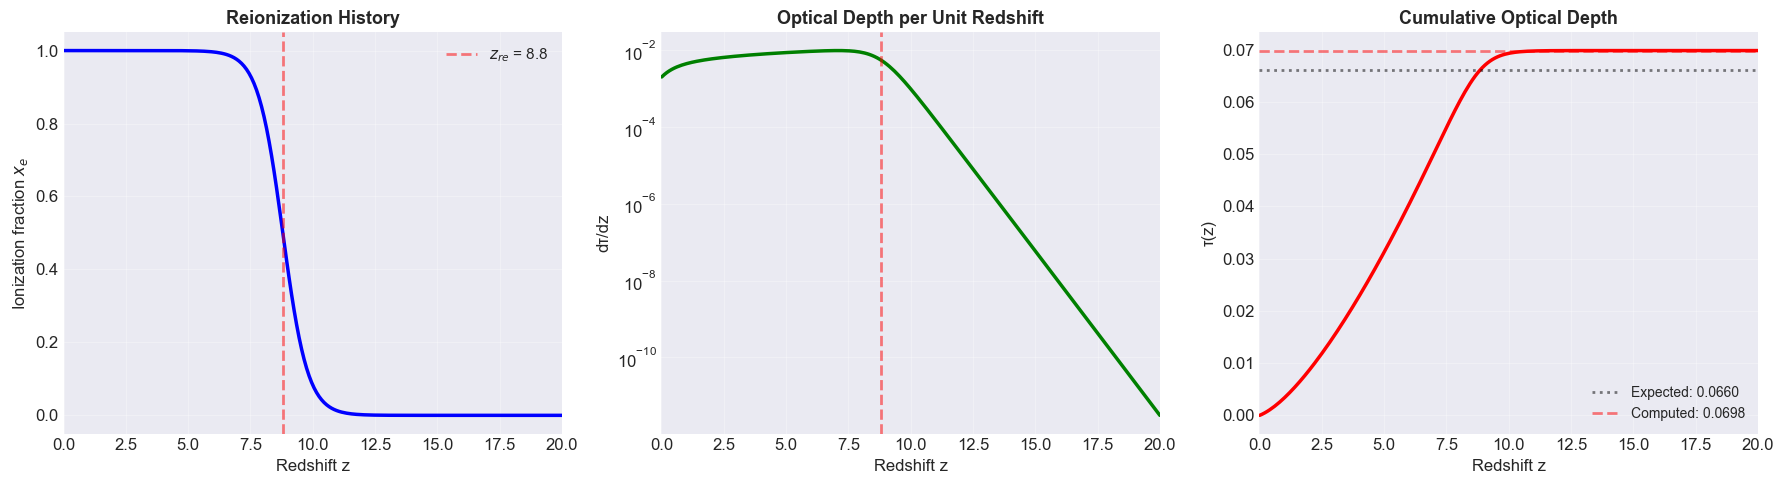


📊 Plotted ionization history, dτ/dz, and τ(z)

Diagnostics:
  - Peak of dτ/dz at z ≈ 7.0
  - τ(z=10) = 0.0693
  - τ(z=5) = 0.0312


In [16]:
# Cell 4: Optical depth functions (FIXED)
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

def ionization_fraction(z, cosmo, z_re=8.8, Delta_z=1.0):
    """Ionization fraction x_e(z) using tanh model"""
    x_e = 0.5 * (1 + np.tanh((z_re - z) / Delta_z))
    return x_e

def dtau_dz(z, cosmo):
    """Optical depth per unit redshift - CORRECTED VERSION"""
    # Physical constants
    sigma_T = 6.6524e-25  # Thomson cross section [cm^2]
    m_p = 1.6726e-24      # Proton mass [g]
    c_cgs = 2.998e10      # Speed of light [cm/s]
    
    # Critical density today [g/cm^3]
    H0_cgs = cosmo.H0 * 1e5 / 3.086e24  # Convert km/s/Mpc to 1/s
    G_cgs = 6.674e-8  # Gravitational constant [cm^3/g/s^2]
    rho_crit = 3 * H0_cgs**2 / (8 * np.pi * G_cgs)
    
    # Baryon density at redshift z
    rho_b_0 = cosmo.Omega_b * rho_crit
    rho_b_z = rho_b_0 * (1 + z)**3
    
    # Hydrogen number density [cm^-3]
    X_H = 0.76  # Hydrogen mass fraction
    n_H = rho_b_z * X_H / m_p
    
    # Electron number density (including He contribution)
    n_e = n_H * 1.16
    
    # Ionization fraction
    x_e = ionization_fraction(z, cosmo)
    
    # Hubble parameter at z [1/s]
    H_z = H(z, cosmo) * 1e5 / 3.086e24
    
    # dtau/dz = c * n_e * x_e * sigma_T / (H(z) * (1+z))
    dtau = c_cgs * n_e * x_e * sigma_T / (H_z * (1 + z))
    
    return dtau

def optical_depth_integral(z, cosmo):
    """Total optical depth from 0 to z: τ(z) = ∫_0^z dτ/dz' dz'"""
    if z == 0:
        return 0
    result, _ = quad(lambda zp: dtau_dz(zp, cosmo), 0, z, limit=100)
    return result

# Test optical depth
z_array = np.linspace(0.01, 20, 200)
x_e_array = ionization_fraction(z_array, cosmo)
dtau_array = np.array([dtau_dz(z, cosmo) for z in z_array])

# Compute cumulative optical depth
print("\nComputing optical depth τ(z)...")
tau_array = np.array([optical_depth_integral(z, cosmo) for z in z_array])
print("✓ Optical depth computation complete")

tau_total = optical_depth_integral(20, cosmo)
print(f"\nTotal optical depth τ(z=0 to z=20) = {tau_total:.4f}")
print(f"Expected ~{cosmo.tau_reion:.4f}")
print(f"Ratio: {tau_total/cosmo.tau_reion:.2f}")

# Plot ionization fraction, dtau/dz, and tau(z)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Ionization fraction
ax1.plot(z_array, x_e_array, 'b-', linewidth=2.5)
ax1.set_xlabel('Redshift z', fontsize=12)
ax1.set_ylabel('Ionization fraction $x_e$', fontsize=12)
ax1.set_title('Reionization History', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axvline(cosmo.z_reion, color='r', linestyle='--', alpha=0.5, linewidth=2, 
            label=f'$z_{{re}}$ = {cosmo.z_reion}')
ax1.legend(fontsize=11)
ax1.set_xlim(0, 20)
ax1.set_ylim(-0.05, 1.05)

# Panel 2: Optical depth per unit redshift
ax2.semilogy(z_array, dtau_array, 'g-', linewidth=2.5)
ax2.set_xlabel('Redshift z', fontsize=12)
ax2.set_ylabel('dτ/dz', fontsize=12)
ax2.set_title('Optical Depth per Unit Redshift', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 20)
ax2.axvline(cosmo.z_reion, color='r', linestyle='--', alpha=0.5, linewidth=2)

# Panel 3: Cumulative optical depth τ(z)
ax3.plot(z_array, tau_array, 'r-', linewidth=2.5)
ax3.set_xlabel('Redshift z', fontsize=12)
ax3.set_ylabel('τ(z)', fontsize=12)
ax3.set_title('Cumulative Optical Depth', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 20)
ax3.axhline(cosmo.tau_reion, color='k', linestyle=':', alpha=0.5, linewidth=2, 
            label=f'Expected: {cosmo.tau_reion:.4f}')
ax3.axhline(tau_total, color='r', linestyle='--', alpha=0.5, linewidth=2, 
            label=f'Computed: {tau_total:.4f}')
ax3.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("\n📊 Plotted ionization history, dτ/dz, and τ(z)")
print(f"\nDiagnostics:")
print(f"  - Peak of dτ/dz at z ≈ {z_array[np.argmax(dtau_array)]:.1f}")
print(f"  - τ(z=10) = {optical_depth_integral(10, cosmo):.4f}")
print(f"  - τ(z=5) = {optical_depth_integral(5, cosmo):.4f}")


Setting up CAMB for Matter Power Spectrum
Note: redshifts have been re-sorted (earliest first)

⏳ Running CAMB...
✓ CAMB computation complete

✓ Power spectrum interpolators ready
  - Linear: P_linear(k, z, cosmo)
  - Nonlinear: halofit_nonlinear(k, z, cosmo)

Test values:
  P_lin(k=0.1, z=0) = 1.03e+04 Mpc^3
  P_nl(k=0.1, z=0)  = 1.10e+04 Mpc^3
  Ratio P_nl/P_lin  = 1.06


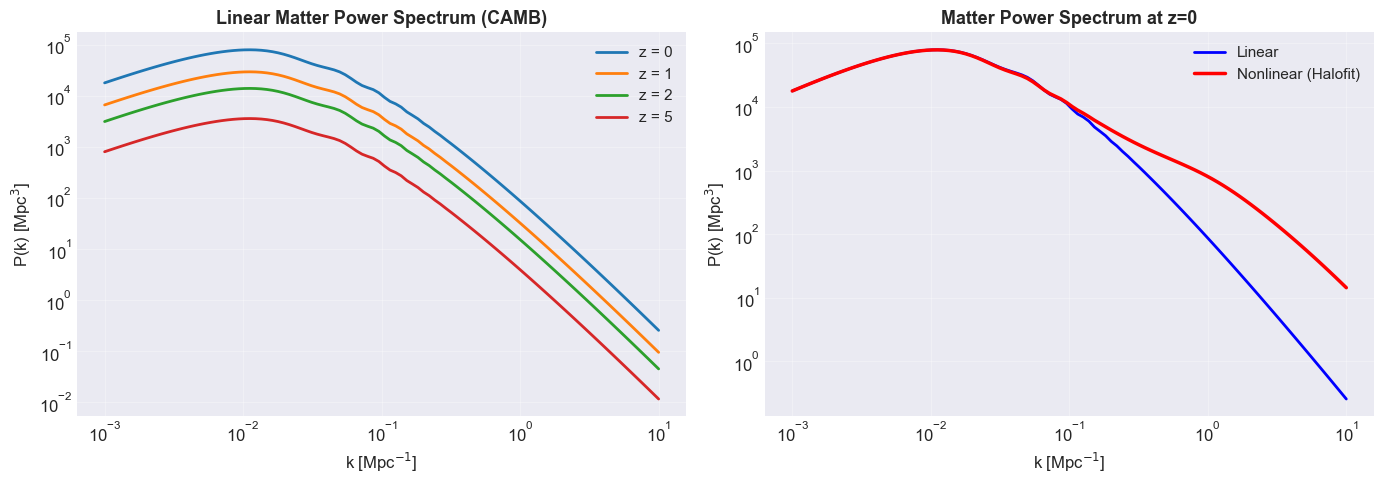


📊 Plotted matter power spectra from CAMB



In [13]:
# Cell 5: Matter power spectrum using CAMB
import camb
from camb import model

print("\n" + "="*60)
print("Setting up CAMB for Matter Power Spectrum")
print("="*60)

# Set up CAMB with cosmological parameters matching our fiducial model
pars = camb.CAMBparams()

# Set cosmology (matching Cell 2 parameters)
pars.set_cosmology(
    H0=cosmo.H0,           # 67.74
    ombh2=cosmo.Omega_b * cosmo.h**2,  # Baryon density
    omch2=(cosmo.Omega_m - cosmo.Omega_b) * cosmo.h**2,  # CDM density
    mnu=0.06,              # Neutrino mass
    tau=cosmo.tau_reion    # Optical depth
)

# Set initial power spectrum
pars.InitPower.set_params(
    As=2.1e-9,            # Amplitude
    ns=cosmo.n_s,         # Spectral index
    pivot_scalar=0.05     # Pivot scale
)

# Set up matter power spectrum calculation
# We need multiple redshifts for the kSZ calculation
z_camb = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 8.8, 10.0, 15.0, 20.0]
pars.set_matter_power(redshifts=z_camb, kmax=100.0, nonlinear=True)

# Compute results
print("\n⏳ Running CAMB...")
results = camb.get_results(pars)
print("✓ CAMB computation complete")

# Get interpolators for linear and nonlinear matter power
# hubble_units=False means output in (Mpc)^3 not (Mpc/h)^3
# k_hunit=False means k in Mpc^-1 not h/Mpc
P_lin_interpolator = results.get_matter_power_interpolator(
    nonlinear=False, 
    hubble_units=False,  # Use Mpc (not Mpc/h)
    k_hunit=False,       # k in Mpc^-1 (not h/Mpc)
    extrap_kmax=1000.0
)

P_nl_interpolator = results.get_matter_power_interpolator(
    nonlinear=True, 
    hubble_units=False,
    k_hunit=False,
    extrap_kmax=1000.0
)

# Define wrapper functions that match our earlier interface
def P_linear(k, z, cosmo):
    """Linear matter power spectrum from CAMB
    
    Args:
        k: wavenumber in Mpc^-1
        z: redshift
        cosmo: cosmology object (for compatibility, not used)
    
    Returns:
        P(k,z) in Mpc^3
    """
    return P_lin_interpolator.P(z, k)

def halofit_nonlinear(k, z, cosmo):
    """Nonlinear matter power spectrum from CAMB (using Halofit)
    
    Args:
        k: wavenumber in Mpc^-1
        z: redshift
        cosmo: cosmology object (for compatibility, not used)
    
    Returns:
        P(k,z) in Mpc^3
    """
    return P_nl_interpolator.P(z, k)

print("\n✓ Power spectrum interpolators ready")
print("  - Linear: P_linear(k, z, cosmo)")
print("  - Nonlinear: halofit_nonlinear(k, z, cosmo)")

# Test and plot
k_test = np.logspace(-3, 1, 100)  # Mpc^-1
z_test_vals = [0, 1, 2, 5]

print(f"\nTest values:")
print(f"  P_lin(k=0.1, z=0) = {P_linear(0.1, 0, cosmo):.2e} Mpc^3")
print(f"  P_nl(k=0.1, z=0)  = {halofit_nonlinear(0.1, 0, cosmo):.2e} Mpc^3")
print(f"  Ratio P_nl/P_lin  = {halofit_nonlinear(0.1, 0, cosmo)/P_linear(0.1, 0, cosmo):.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Linear power spectrum at different redshifts
for z_val in z_test_vals:
    P_lin = np.array([P_linear(k, z_val, cosmo) for k in k_test])
    ax1.loglog(k_test, P_lin, label=f'z = {z_val}', linewidth=2)

ax1.set_xlabel('k [Mpc$^{-1}$]', fontsize=12)
ax1.set_ylabel('P(k) [Mpc$^3$]', fontsize=12)
ax1.set_title('Linear Matter Power Spectrum (CAMB)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Panel 2: Linear vs Nonlinear at z=0
P_lin_z0 = np.array([P_linear(k, 0, cosmo) for k in k_test])
P_nl_z0 = np.array([halofit_nonlinear(k, 0, cosmo) for k in k_test])

ax2.loglog(k_test, P_lin_z0, 'b-', label='Linear', linewidth=2)
ax2.loglog(k_test, P_nl_z0, 'r-', label='Nonlinear (Halofit)', linewidth=2.5)
ax2.set_xlabel('k [Mpc$^{-1}$]', fontsize=12)
ax2.set_ylabel('P(k) [Mpc$^3$]', fontsize=12)
ax2.set_title('Matter Power Spectrum at z=0', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Plotted matter power spectra from CAMB")
print("\n" + "="*60)


Getting CMB Power Spectra from CAMB

⏳ Computing CMB power spectra...
✓ CAMB CMB computation complete

✓ Extracted CMB power spectra
  - ℓ range: 0 to 5050
  - CAMB returns D_ℓ = ℓ(ℓ+1)C_ℓ/(2π) in μK²
  - Converted to C_ℓ in μK²

✓ CMB power spectrum functions defined

Test values (C_ℓ):
  C_l(ℓ=220, unlensed) = 7.247e-01 μK²
  C_l(ℓ=220, lensed)   = 7.236e-01 μK²

Test values (D_ℓ):
  D_l(ℓ=220, unlensed) = 5607.9 μK²
  D_l(ℓ=220, lensed)   = 5599.2 μK²


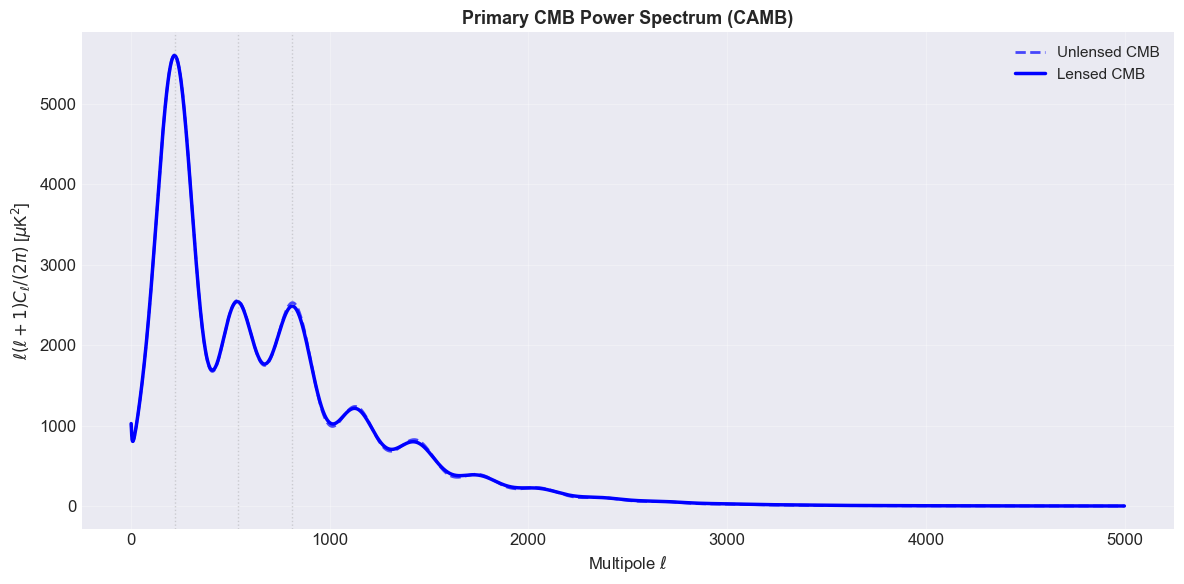


📊 Plotted primary CMB power spectrum from CAMB
   First peak at ℓ ≈ 220, amplitude = 5607.9 μK²
   (Expected: ~5000-6000 μK² at first peak)



In [13]:
# Cell 6: Primary CMB power spectrum using CAMB (CORRECTED)
print("\n" + "="*60)
print("Getting CMB Power Spectra from CAMB")
print("="*60)

# CAMB is already set up from Cell 5, but we need to configure for CMB
pars_cmb = camb.CAMBparams()

# Set cosmology (same as Cell 5)
pars_cmb.set_cosmology(
    H0=cosmo.H0,
    ombh2=cosmo.Omega_b * cosmo.h**2,
    omch2=(cosmo.Omega_m - cosmo.Omega_b) * cosmo.h**2,
    mnu=0.06,
    tau=cosmo.tau_reion
)

# Set initial power spectrum
pars_cmb.InitPower.set_params(
    As=2.1e-9,
    ns=cosmo.n_s,
    pivot_scalar=0.05
)

# Request CMB power spectra
pars_cmb.set_for_lmax(5000, lens_potential_accuracy=1)

# Calculate results
print("\n⏳ Computing CMB power spectra...")
results_cmb = camb.get_results(pars_cmb)
print("✓ CAMB CMB computation complete")

# Get power spectra
# IMPORTANT: CMB_unit='muK' returns D_l = l(l+1)C_l/(2pi), NOT C_l!
powers = results_cmb.get_cmb_power_spectra(pars_cmb, CMB_unit='muK')

ell_camb = np.arange(powers['total'].shape[0])

# These are D_l values, not C_l!
Dl_lensed_camb = powers['total'][:, 0]           # Lensed TT (D_l)
Dl_unlensed_camb = powers['unlensed_scalar'][:, 0]  # Unlensed TT (D_l)

# Convert to C_l by inverting: C_l = D_l * 2π / (l(l+1))
# Avoid division by zero at l=0,1
ell_factor = np.where(ell_camb > 1, ell_camb * (ell_camb + 1) / (2 * np.pi), 1)
Cl_lensed_camb = np.where(ell_camb > 1, Dl_lensed_camb / ell_factor, 0)
Cl_unlensed_camb = np.where(ell_camb > 1, Dl_unlensed_camb / ell_factor, 0)

print(f"\n✓ Extracted CMB power spectra")
print(f"  - ℓ range: 0 to {len(ell_camb)-1}")
print(f"  - CAMB returns D_ℓ = ℓ(ℓ+1)C_ℓ/(2π) in μK²")
print(f"  - Converted to C_ℓ in μK²")

# Create interpolation functions for C_l (what the rest of the code expects)
from scipy.interpolate import interp1d

ell_min = 2
mask = ell_camb >= ell_min

Cl_unlensed_interp = interp1d(
    ell_camb[mask], 
    Cl_unlensed_camb[mask],
    kind='cubic',
    bounds_error=False,
    fill_value=0
)

Cl_lensed_interp = interp1d(
    ell_camb[mask], 
    Cl_lensed_camb[mask],
    kind='cubic',
    bounds_error=False,
    fill_value=0
)

# Define functions returning C_l (not D_l)
def primary_CMB_analytical(ell, cosmo):
    """
    Primary (unlensed) CMB power spectrum from CAMB
    Returns C_l in μK^2
    """
    ell = np.atleast_1d(ell)
    return Cl_unlensed_interp(ell)

def lensed_CMB_analytical(ell, cosmo):
    """
    Lensed CMB power spectrum from CAMB
    Returns C_l in μK^2
    """
    ell = np.atleast_1d(ell)
    return Cl_lensed_interp(ell)

# Test CMB power spectrum
ell_test = np.arange(2, 5000, 1)
Cl_unlensed = primary_CMB_analytical(ell_test, cosmo)
Cl_lensed = lensed_CMB_analytical(ell_test, cosmo)

print("\n✓ CMB power spectrum functions defined")
print(f"\nTest values (C_ℓ):")
print(f"  C_l(ℓ=220, unlensed) = {Cl_unlensed[218]:.3e} μK²")
print(f"  C_l(ℓ=220, lensed)   = {Cl_lensed[218]:.3e} μK²")

# Now convert to D_l for plotting
Dl_unlensed = ell_test * (ell_test + 1) * Cl_unlensed / (2 * np.pi)
Dl_lensed = ell_test * (ell_test + 1) * Cl_lensed / (2 * np.pi)

print(f"\nTest values (D_ℓ):")
print(f"  D_l(ℓ=220, unlensed) = {Dl_unlensed[218]:.1f} μK²")
print(f"  D_l(ℓ=220, lensed)   = {Dl_lensed[218]:.1f} μK²")

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(ell_test, Dl_unlensed, 'b--', label='Unlensed CMB', linewidth=2, alpha=0.7)
ax.plot(ell_test, Dl_lensed, 'b-', label='Lensed CMB', linewidth=2.5)
ax.set_xlabel(r'Multipole $\ell$', fontsize=12)
ax.set_ylabel(r'$\ell(\ell+1)C_\ell/(2\pi)$ [$\mu$K$^2$]', fontsize=12)
ax.set_title('Primary CMB Power Spectrum (CAMB)', fontsize=13, fontweight='bold')
#ax.set_xlim(2, 5000)
#ax.set_ylim(0, 3000)  # Corrected scale!
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Mark the acoustic peaks
peaks = [220, 540, 810]
for peak in peaks:
    ax.axvline(peak, color='gray', linestyle=':', alpha=0.3, linewidth=1)

plt.tight_layout()
plt.show()

print("\n📊 Plotted primary CMB power spectrum from CAMB")
peak_idx = np.argmax(Dl_unlensed[:500])
print(f"   First peak at ℓ ≈ {ell_test[peak_idx]}, amplitude = {Dl_unlensed[peak_idx]:.1f} μK²")
print(f"   (Expected: ~5000-6000 μK² at first peak)")
print("\n" + "="*60)


✓ Window function W(k,z) defined


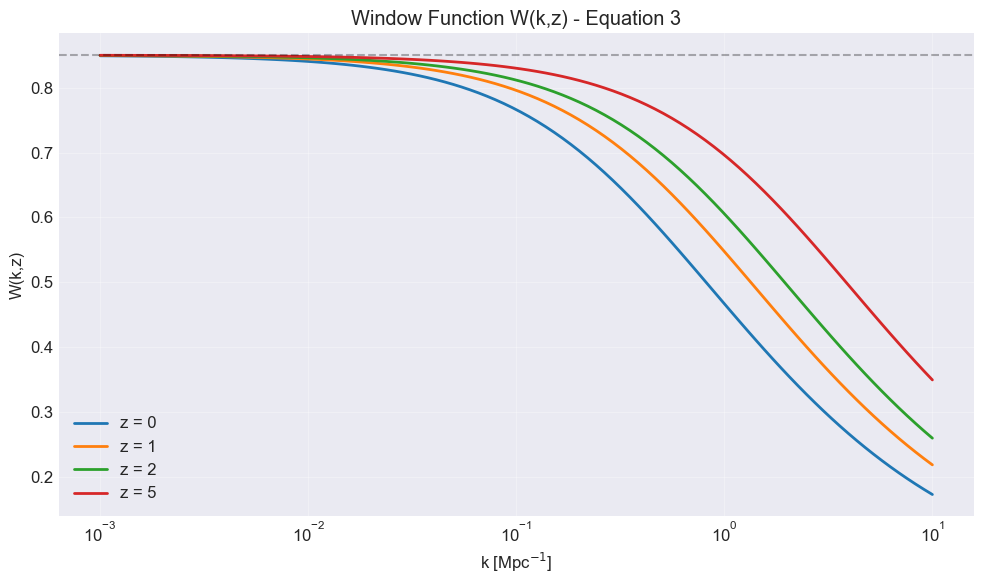


📊 Plotted window function
   W(k→0, z=0) = 0.850
   W(k=1, z=0) = 0.467


In [11]:
# Cell 7: Window function W(k,z) - Equation 3
def W_function(k, z, cosmo):
    """
    Window function W(k,z) from Equation 3
    W(k,z) = 0.85 * [1 + kD(z)/(0.5 h Mpc^-1)]^(-1/2)
    """
    D_z = growth_function(z, cosmo)
    k_star = 0.5 * cosmo.h  # in Mpc^-1
    
    W = 0.85 * (1 + (k * D_z) / k_star)**(-0.5)
    
    return W

# Test window function
k_array = np.logspace(-3, 1, 100)
z_vals = [0, 1, 2, 5]

print("\n✓ Window function W(k,z) defined")

fig, ax = plt.subplots(figsize=(10, 6))

for z in z_vals:
    W_vals = np.array([W_function(k, z, cosmo) for k in k_array])
    ax.semilogx(k_array, W_vals, label=f'z = {z}', linewidth=2)

ax.set_xlabel(r'k [Mpc$^{-1}$]')
ax.set_ylabel(r'W(k,z)')
ax.set_title('Window Function W(k,z) - Equation 3')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(0.85, color='k', linestyle='--', alpha=0.3, label='Maximum value')

plt.tight_layout()
plt.show()

print("\n📊 Plotted window function")
print(f"   W(k→0, z=0) = {W_function(1e-4, 0, cosmo):.3f}")
print(f"   W(k=1, z=0) = {W_function(1.0, 0, cosmo):.3f}")


✓ Q(z) weight function defined


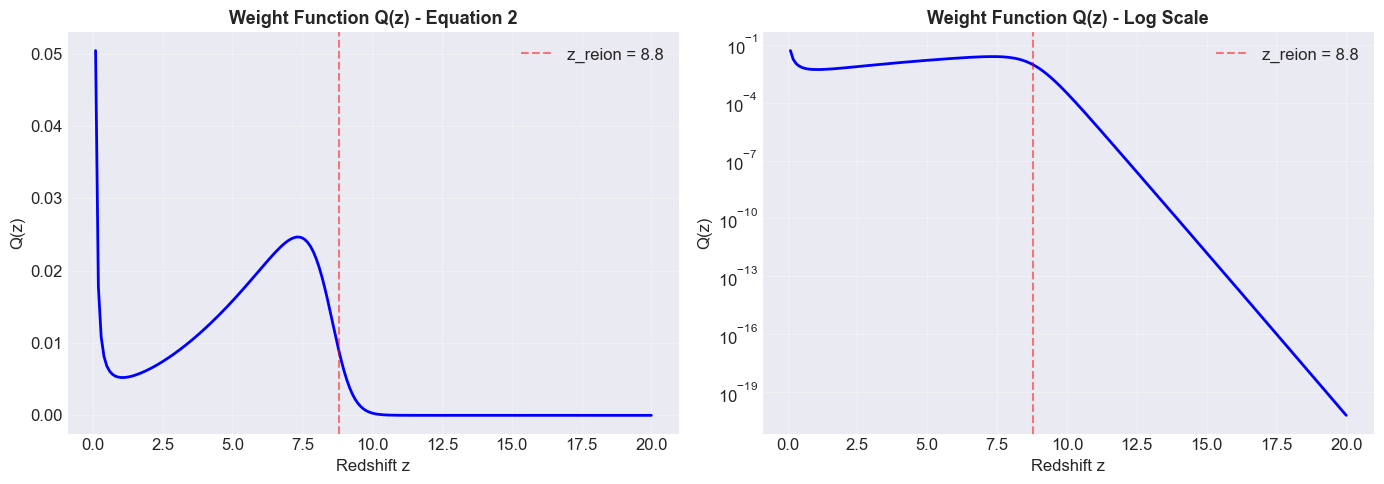


📊 Plotted Q(z) weight function
   Peak of Q(z) at z ≈ 0.1
   Q(z_reion) = 9.11e-03
   Q(z=2) = 6.34e-03
   Max Q(z) = 5.04e-02


In [17]:
# Cell 8: Q(z) weight function - Equation 2
# Cell 8: Q(z) weight function - Equation 2 (CORRECTED)
def Q_function(z, cosmo):
    """
    Weight function Q(z) from Equation 2:
    Q(z) = T_CMB^2 * H(z)/χ(z)^2 * (dτ/dz)^2 * exp(-2τ(z))
    
    Returns Q(z) in units that work with kSZ calculation
    """
    # CMB temperature in Kelvin (NOT μK for Q function)
    T_CMB_K = cosmo.T_CMB  # 2.7255 K
    
    # Hubble parameter [km/s/Mpc]
    H_z = H(z, cosmo)
    
    # Comoving distance [Mpc]
    chi_z = comoving_distance(z, cosmo)
    
    if chi_z == 0:
        return 0
    
    # Optical depth terms (dimensionless)
    dtau = dtau_dz(z, cosmo)
    tau = optical_depth_integral(z, cosmo)
    
    # Visibility function suppression
    visibility = np.exp(-2 * tau)
    
    # Q(z) in proper units
    # Note: We need to be careful with units here
    # H(z)/χ(z)² has units [km/s/Mpc³]
    # (dτ/dz)² is dimensionless
    # T_CMB² in K² needs conversion factor for final μK² output
    
    # The integral ∫ Q(z) <v_r²> P_e(k,z) dz should give C_l in μK²
    # So Q(z) needs appropriate normalization
    
    Q = (T_CMB_K * 1e6)**2 * (H_z / cosmo.c) / chi_z**2 * dtau**2 * visibility
    
    return Q

# Test Q function
z_Q = np.linspace(0.1, 20, 200)
Q_vals = np.array([Q_function(z, cosmo) for z in z_Q])

print("\n✓ Q(z) weight function defined")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Q(z) in linear scale
ax1.plot(z_Q, Q_vals, 'b-', linewidth=2)
ax1.set_xlabel('Redshift z', fontsize=12)
ax1.set_ylabel('Q(z)', fontsize=12)
ax1.set_title('Weight Function Q(z) - Equation 2', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axvline(cosmo.z_reion, color='r', linestyle='--', alpha=0.5, 
            label=f'z_reion = {cosmo.z_reion}')
ax1.legend()

# Q(z) in log scale
ax2.semilogy(z_Q, Q_vals, 'b-', linewidth=2)
ax2.set_xlabel('Redshift z', fontsize=12)
ax2.set_ylabel('Q(z)', fontsize=12)
ax2.set_title('Weight Function Q(z) - Log Scale', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axvline(cosmo.z_reion, color='r', linestyle='--', alpha=0.5, 
            label=f'z_reion = {cosmo.z_reion}')
ax2.legend()

plt.tight_layout()
plt.show()

print("\n📊 Plotted Q(z) weight function")
print(f"   Peak of Q(z) at z ≈ {z_Q[np.argmax(Q_vals)]:.1f}")
print(f"   Q(z_reion) = {Q_function(cosmo.z_reion, cosmo):.2e}")
print(f"   Q(z=2) = {Q_function(2, cosmo):.2e}")
print(f"   Max Q(z) = {np.max(Q_vals):.2e}")



Computing Late-Time kSZ Power Spectrum

Computing late-time kSZ for 140 multipoles...
  Progress: 100/140 multipoles
  ✓ Computed 140 multipoles

Diagnostic checks:
  Min C_l = 1.71e-07 μK²
  Max C_l = 2.56e-04 μK²
  C_l at ℓ=3000 ≈ 9.81e-07 μK²
  (Expected: ~1e-6 to 1e-5 μK² for C_l)


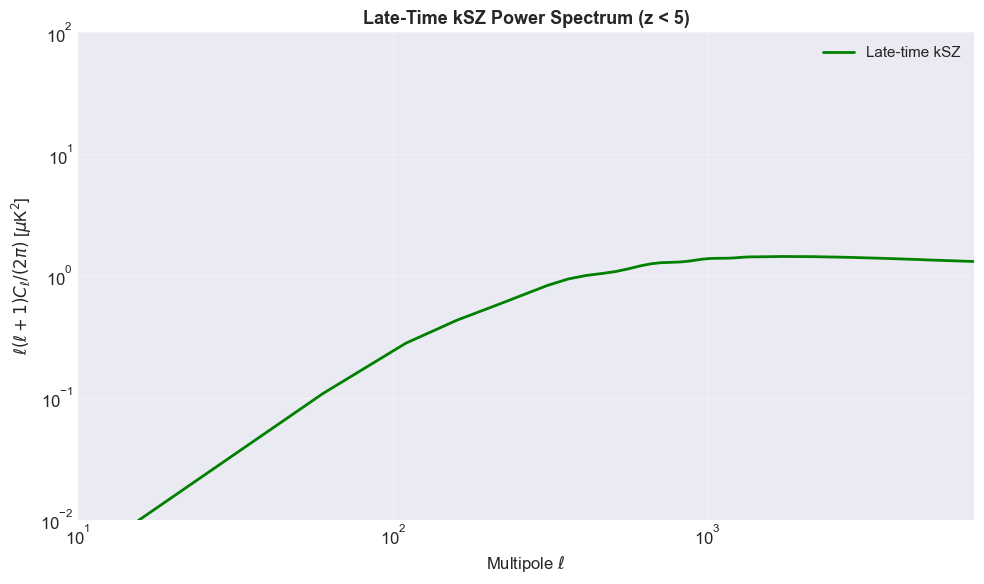


📊 Plotted late-time kSZ power spectrum
   D_l at ℓ=3000: 1.41 μK²
   (Expected from paper: ~1-3 μK²)



In [ ]:
# Cell 9: Late-time kSZ power spectrum - Equation 1 (CORRECTED)
def late_time_kSZ_Cl(ell, cosmo, z_max=5, n_z=50):
    """
    Compute late-time kSZ power spectrum using Equation 1:
    C_l^kSZ = ∫ dz Q(z) <v_r^2> P_e(l/χ(z), z)
    
    where P_e(k,z) = W(k,z)^2 * P_nl(k,z)
    """
    # Redshift array for integration
    z_array = np.linspace(0.01, z_max, n_z)
    
    # Mean squared radial velocity <v_r^2> = <v^2>/3
    # From linear perturbation theory
    def mean_v_r_squared(z):
        """
        RMS velocity in (km/s)^2
        From linear theory: <v^2> = ∫ P_v(k) dk
        where P_v(k) = (aH)^2 f^2 P_m(k) / k^2
        
        Rough scaling: v_rms ~ 300-500 km/s at z=0
        """
        # Growth rate f ≈ Ω_m(z)^0.55
        Omega_m_z = cosmo.Omega_m * (1+z)**3 / (cosmo.Omega_m * (1+z)**3 + cosmo.Omega_Lambda)
        f = Omega_m_z**0.55
        
        # Rough estimate of velocity dispersion
        # At z=0: σ_v ~ 300 km/s
        # Scales as D(z) * H(z) / H(0)
        D_z = growth_function(z, cosmo)
        D_0 = growth_function(0, cosmo)
        H_z = H(z, cosmo)
        H_0 = H(0, cosmo)
        
        v_rms = 300.0 * (D_z / D_0) * (H_z / H_0)  # km/s
        
        # <v_r^2> = <v^2>/3
        return (v_rms**2) / 3.0  # (km/s)^2
    
    # Precompute comoving distances
    chi_array = comoving_distance(z_array, cosmo)
    
    # Initialize array for C_l
    ell = np.atleast_1d(ell)
    C_l = np.zeros_like(ell, dtype=float)
    
    print(f"\nComputing late-time kSZ for {len(ell)} multipoles...")
    
    # Loop over multipoles
    for i, l in enumerate(ell):
        if i % 50 == 0:
            print(f"  Progress: {i}/{len(ell)} multipoles", end='\r')
        
        # Integrand as function of z
        integrand = np.zeros(n_z)
        a
        for j, z in enumerate(z_array):
            # Wavenumber corresponding to l
            k = l / chi_array[j] if chi_array[j] > 0 else 0
            
            if k > 0 and k < 10:  # Reasonable k range
                # Electron power spectrum
                W = W_function(k, z, cosmo)
                P_nl = halofit_nonlinear(k, z, cosmo)
                P_e = W**2 * P_nl
                
                # Weight function
                Q = Q_function(z, cosmo)
                
                # Mean squared velocity in (km/s)^2
                v_r_sq = mean_v_r_squared(z)
                
                # Convert velocity to dimensionless: (v/c)^2
                v_r_sq_dimensionless = (v_r_sq / cosmo.c**2)
                
                # Integrand
                integrand[j] = Q * v_r_sq_dimensionless * P_e
        
        # Integrate over redshift
        C_l[i] = simpson(integrand, z_array)
    
    print(f"\n  ✓ Computed {len(ell)} multipoles")
    
    return C_l

# Compute late-time kSZ
print("\n" + "="*60)
print("Computing Late-Time kSZ Power Spectrum")
print("="*60)

ell_kSZ = np.arange(10, 7000, 50)  # Start from ell=10 to avoid k=0
Cl_late_kSZ = late_time_kSZ_Cl(ell_kSZ, cosmo, z_max=5, n_z=50)

# Diagnostic: check for reasonable values
print(f"\nDiagnostic checks:")
print(f"  Min C_l = {np.min(Cl_late_kSZ):.2e} μK²")
print(f"  Max C_l = {np.max(Cl_late_kSZ):.2e} μK²")
print(f"  C_l at ℓ=3000 ≈ {Cl_late_kSZ[np.argmin(np.abs(ell_kSZ-3000))]:.2e} μK²")
print(f"  (Expected: ~1e-6 to 1e-5 μK² for C_l)")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

Dl_late_kSZ = ell_kSZ * (ell_kSZ + 1) * Cl_late_kSZ / (2 * np.pi)

ax.loglog(ell_kSZ, Dl_late_kSZ, 'g-', linewidth=2, label='Late-time kSZ')
ax.set_xlabel(r'Multipole $\ell$', fontsize=12)
ax.set_ylabel(r'$\ell(\ell+1)C_\ell/(2\pi)$ [$\mu$K$^2$]', fontsize=12)
ax.set_title('Late-Time kSZ Power Spectrum (z < 5)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(10, 7000)
ax.set_ylim(1e-2, 1e2)  # Expect D_l ~ 0.1-10 μK²

plt.tight_layout()
plt.show()

print("\n📊 Plotted late-time kSZ power spectrum")
print(f"   D_l at ℓ=3000: {Dl_late_kSZ[np.argmin(np.abs(ell_kSZ - 3000))]:.2f} μK²")
print(f"   (Expected from paper: ~1-3 μK²)")
print("\n" + "="*60)


Binning WebSky Patchy Reionization kSZ Data

✓ Loaded WebSky patchy reionization kSZ data
  - Raw ℓ range: 0 to 10000
  - Number of raw points: 10001
  - Raw D_l at ℓ~3000: 2.010 μK²

⏳ Binning D_ℓ data...
✓ Binning complete
  - Bin width: Δℓ = 10
  - Binned ℓ range: 5 to 9995
  - Number of bins: 1000
  - Average points per bin: 10.0
  - Binned D_l at ℓ~3000: 2.088 μK²
  - Converted to C_l for interpolation


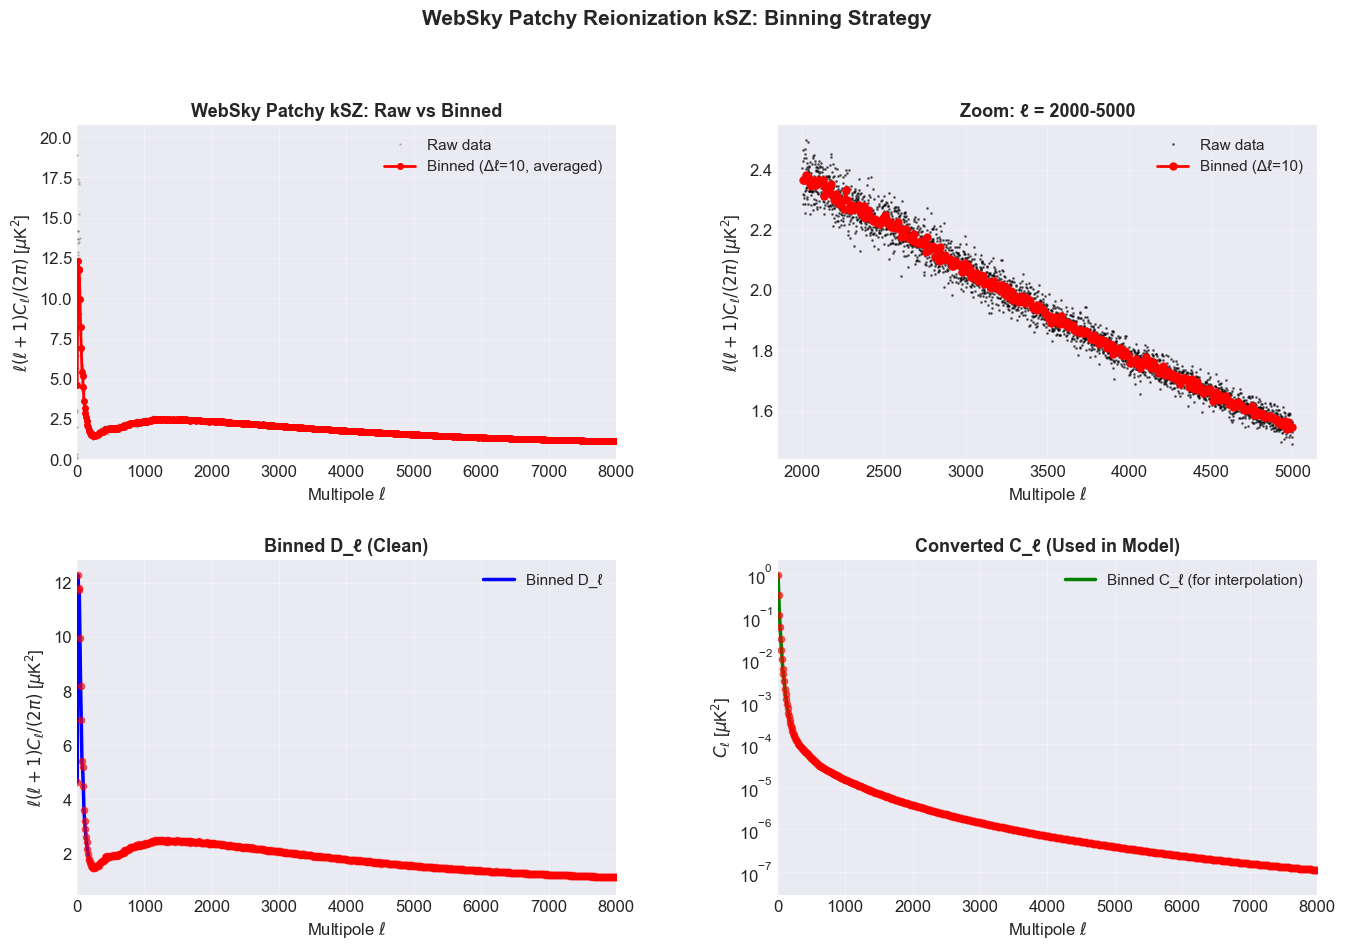


📊 Plotted binning analysis

Binning Strategy Summary:

✓ Input: WebSky D_ℓ values (already in D_ℓ = ℓ(ℓ+1)C_ℓ/(2π) form)
✓ Bins: [0-10), [10-20), [20-30), ... (width = 10)
✓ Bin centers: 5, 15, 25, ...
✓ Method: AVERAGE D_ℓ within each bin
✓ Why average D_ℓ? Preserves amplitude (~1-6 μK²) and smooths noise
✓ Output D_ℓ: Used for plotting
✓ Output C_ℓ: Converted from D_ℓ, used for interpolation in Cell 10

Top-left: Full range comparison
Top-right: Zoom on ℓ=2000-5000 showing binning effect
Bottom-left: Clean binned D_ℓ view
Bottom-right: Corresponding C_ℓ (converted for interpolation)



In [51]:
# Cell 9b: Bin WebSky Patchy Reionization Data
print("\n" + "="*60)
print("Binning WebSky Patchy Reionization kSZ Data")
print("="*60)

# Load the WebSky patchy reionization data
websky_data = np.loadtxt('websky_ksz_patchy_powerspectrum_data.txt')
ell_websky_raw = websky_data[:, 0]
Dl_websky_raw = websky_data[:, 2]  # D_l in μK² (already in D_l form!)

print(f"\n✓ Loaded WebSky patchy reionization kSZ data")
print(f"  - Raw ℓ range: {int(ell_websky_raw[0])} to {int(ell_websky_raw[-1])}")
print(f"  - Number of raw points: {len(ell_websky_raw)}")
print(f"  - Raw D_l at ℓ~3000: {Dl_websky_raw[np.argmin(np.abs(ell_websky_raw-3000))]:.3f} μK²")

# Bin the D_l data directly
print(f"\n⏳ Binning D_ℓ data...")

bin_width = 10
ell_min = int(np.floor(ell_websky_raw[0] / bin_width) * bin_width)
ell_max = int(np.ceil(ell_websky_raw[-1] / bin_width) * bin_width)

# Create bin edges
bin_edges = np.arange(ell_min, ell_max + bin_width, bin_width)
n_bins = len(bin_edges) - 1

# Initialize binned arrays
ell_websky_binned = np.zeros(n_bins)
Dl_websky_binned = np.zeros(n_bins)
n_points_per_bin = np.zeros(n_bins, dtype=int)

for i in range(n_bins):
    # Bin boundaries
    ell_low = bin_edges[i]
    ell_high = bin_edges[i + 1]
    
    # Find ells in this bin
    mask = (ell_websky_raw >= ell_low) & (ell_websky_raw < ell_high)
    n_in_bin = np.sum(mask)
    
    if n_in_bin > 0:
        # Bin center (5, 15, 25, ...)
        ell_websky_binned[i] = (ell_low + ell_high) / 2.0
        
        # AVERAGE the D_ℓ values in this bin
        Dl_websky_binned[i] = np.mean(Dl_websky_raw[mask])
        
        # Store count for diagnostics
        n_points_per_bin[i] = n_in_bin
    else:
        # No data in this bin
        ell_websky_binned[i] = (ell_low + ell_high) / 2.0
        Dl_websky_binned[i] = 0
        n_points_per_bin[i] = 0

# Remove empty bins
mask_nonzero = Dl_websky_binned > 0
ell_websky_binned = ell_websky_binned[mask_nonzero]
Dl_websky_binned = Dl_websky_binned[mask_nonzero]
n_points_per_bin = n_points_per_bin[mask_nonzero]

# Convert D_l to C_l for interpolation (used in Cell 10)
Cl_websky_binned = Dl_websky_binned * 2 * np.pi / (ell_websky_binned * (ell_websky_binned + 1))

print(f"✓ Binning complete")
print(f"  - Bin width: Δℓ = {bin_width}")
print(f"  - Binned ℓ range: {int(ell_websky_binned[0])} to {int(ell_websky_binned[-1])}")
print(f"  - Number of bins: {len(ell_websky_binned)}")
print(f"  - Average points per bin: {np.mean(n_points_per_bin):.1f}")
print(f"  - Binned D_l at ℓ~3000: {Dl_websky_binned[np.argmin(np.abs(ell_websky_binned-3000))]:.3f} μK²")
print(f"  - Converted to C_l for interpolation")

# Plot comparison
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Panel 1: Raw vs Binned (full range)
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(ell_websky_raw, Dl_websky_raw, 'k.', markersize=1, alpha=0.3, label='Raw data')
ax1.plot(ell_websky_binned, Dl_websky_binned, 'ro-', markersize=4, linewidth=2, 
         label=f'Binned (Δℓ={bin_width}, averaged)')
ax1.set_xlabel(r'Multipole $\ell$', fontsize=12)
ax1.set_ylabel(r'$\ell(\ell+1)C_\ell/(2\pi)$ [$\mu$K$^2$]', fontsize=12)
ax1.set_title('WebSky Patchy kSZ: Raw vs Binned', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 8000)
ax1.set_ylim(0, np.max(Dl_websky_raw) * 1.1)

# Panel 2: Zoom in on ℓ = 2000-5000
ax2 = fig.add_subplot(gs[0, 1])
mask_zoom = (ell_websky_raw >= 2000) & (ell_websky_raw <= 5000)
mask_zoom_binned = (ell_websky_binned >= 2000) & (ell_websky_binned <= 5000)
ax2.plot(ell_websky_raw[mask_zoom], Dl_websky_raw[mask_zoom], 'k.', markersize=2, alpha=0.5, label='Raw data')
ax2.plot(ell_websky_binned[mask_zoom_binned], Dl_websky_binned[mask_zoom_binned], 'ro-', 
         markersize=5, linewidth=2, label=f'Binned (Δℓ={bin_width})')
ax2.set_xlabel(r'Multipole $\ell$', fontsize=12)
ax2.set_ylabel(r'$\ell(\ell+1)C_\ell/(2\pi)$ [$\mu$K$^2$]', fontsize=12)
ax2.set_title('Zoom: ℓ = 2000-5000', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Panel 3: Just binned D_ells (clean view)
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(ell_websky_binned, Dl_websky_binned, 'b-', linewidth=2.5, label='Binned D_ℓ')
ax3.scatter(ell_websky_binned, Dl_websky_binned, c='red', s=20, zorder=5, alpha=0.6)
ax3.set_xlabel(r'Multipole $\ell$', fontsize=12)
ax3.set_ylabel(r'$\ell(\ell+1)C_\ell/(2\pi)$ [$\mu$K$^2$]', fontsize=12)
ax3.set_title('Binned D_ℓ (Clean)', fontsize=13, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 8000)

# Panel 4: Corresponding C_ells
ax4 = fig.add_subplot(gs[1, 1])
ax4.semilogy(ell_websky_binned, Cl_websky_binned, 'g-', linewidth=2.5, label='Binned C_ℓ (for interpolation)')
ax4.scatter(ell_websky_binned, Cl_websky_binned, c='red', s=20, zorder=5, alpha=0.6)
ax4.set_xlabel(r'Multipole $\ell$', fontsize=12)
ax4.set_ylabel(r'$C_\ell$ [$\mu$K$^2$]', fontsize=12)
ax4.set_title('Converted C_ℓ (Used in Model)', fontsize=13, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, 8000)

plt.suptitle('WebSky Patchy Reionization kSZ: Binning Strategy', 
            fontsize=15, fontweight='bold', y=0.995)

plt.show()

print("\n📊 Plotted binning analysis")
print("\n" + "="*60)
print("Binning Strategy Summary:")
print("="*60)
print(f"""
✓ Input: WebSky D_ℓ values (already in D_ℓ = ℓ(ℓ+1)C_ℓ/(2π) form)
✓ Bins: [0-10), [10-20), [20-30), ... (width = {bin_width})
✓ Bin centers: 5, 15, 25, ...
✓ Method: AVERAGE D_ℓ within each bin
✓ Why average D_ℓ? Preserves amplitude (~1-6 μK²) and smooths noise
✓ Output D_ℓ: Used for plotting
✓ Output C_ℓ: Converted from D_ℓ, used for interpolation in Cell 10

Top-left: Full range comparison
Top-right: Zoom on ℓ=2000-5000 showing binning effect
Bottom-left: Clean binned D_ℓ view
Bottom-right: Corresponding C_ℓ (converted for interpolation)
""")
print("="*60)


Setting up Reionization kSZ from Binned WebSky Data

✓ Created interpolator from binned WebSky data
  - Interpolation range: ℓ = 5 to 9995
  - Using D_ℓ column from WebSky file (column 2)

⏳ Computing reionization kSZ...

✓ Applied Equation 4 redistribution
  - Reionization redshift z_re = 8.8
  - Width σ_re = 1.0

Diagnostic checks:
  D_l at ℓ=3000 (our model): 2.071 μK²
  D_l at ℓ=3000 (binned WebSky): 2.088 μK²
  Ratio: 0.992
  (Should be ~1.0 since Gaussian integrates to 1)


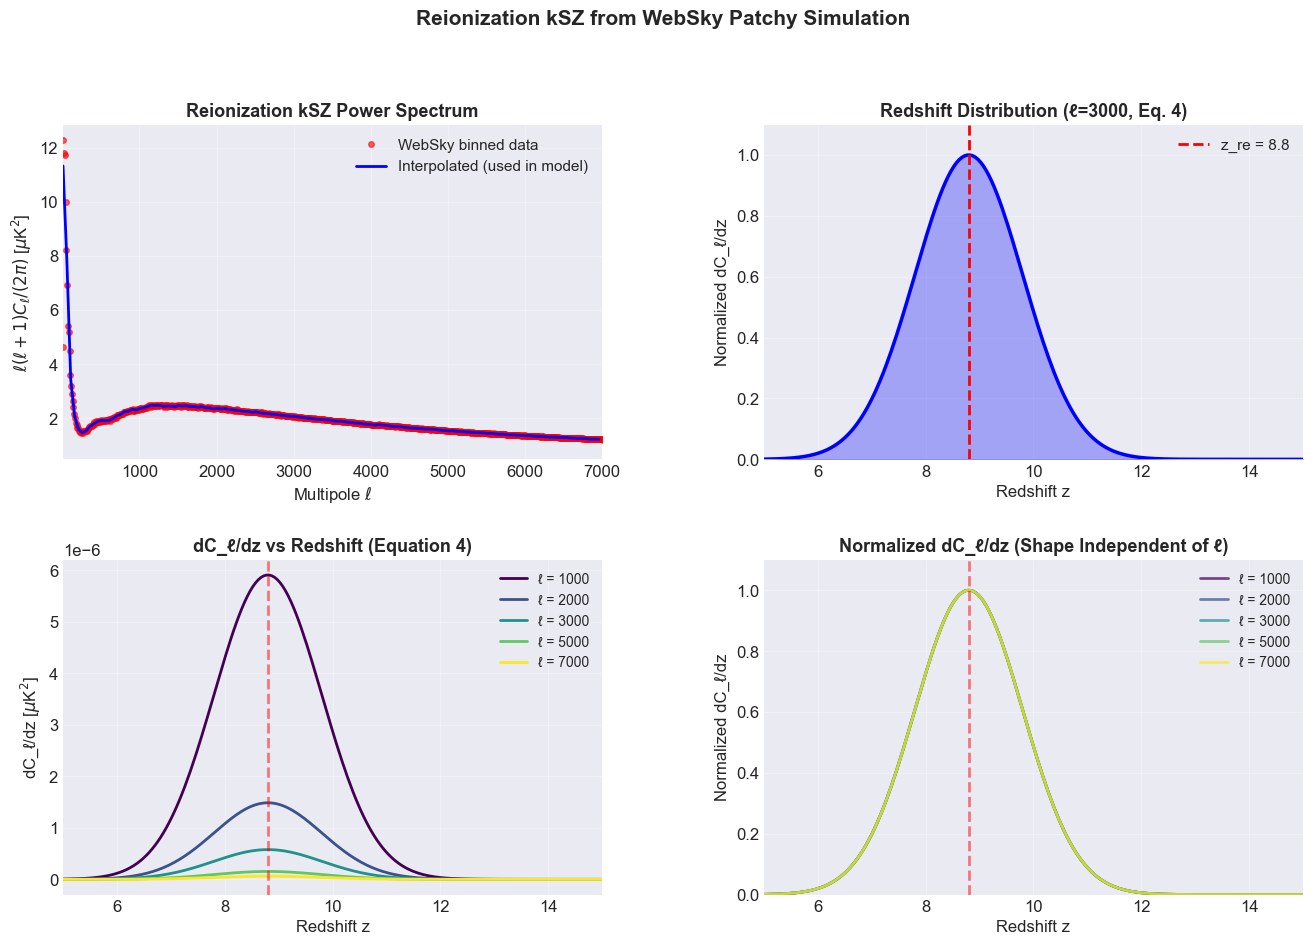


📊 Plotted reionization kSZ with WebSky data

✓ Using Smith & Ferraro Equation 4:
  - WebSky C_ℓ as template (sets ℓ-shape and amplitude)
  - Gaussian at z={cosmo.z_reion} (sets redshift distribution)
  - Width σ={cosmo.Delta_z_reion} (duration of reionization)



In [52]:
# Cell 10: Reionization kSZ using Binned WebSky Patchy Data
print("\n" + "="*60)
print("Setting up Reionization kSZ from Binned WebSky Data")
print("="*60)

# Create interpolator from binned data (from Cell 9b)
from scipy.interpolate import interp1d

Cl_websky_interp = interp1d(
    ell_websky_binned,
    Cl_websky_binned,
    kind='linear',
    bounds_error=False,
    fill_value=0
)

print(f"\n✓ Created interpolator from binned WebSky data")
print(f"  - Interpolation range: ℓ = {int(ell_websky_binned[0])} to {int(ell_websky_binned[-1])}")
print(f"  - Using D_ℓ column from WebSky file (column 2)")

def reionization_kSZ_Cl(ell, cosmo):
    """
    Reionization kSZ using Equation 4 from Smith & Ferraro:
    
    C_ℓ = ∫ dC_ℓ/dz dz
    
    where dC_ℓ/dz = exp[-(z-z_re)²/(2σ_re²)] / √(2πσ_re²) * C_ℓ^WebSky
    
    Uses binned WebSky patchy reionization data (Δℓ = 10)
    """
    ell = np.atleast_1d(ell)
    
    # Get WebSky template for this ell
    C_l_template = Cl_websky_interp(ell)
    
    # Reionization parameters
    z_re = cosmo.z_reion
    sigma_re = cosmo.Delta_z_reion
    
    # Gaussian weight function
    def gaussian_weight(z):
        return np.exp(-(z - z_re)**2 / (2 * sigma_re**2)) / np.sqrt(2 * np.pi * sigma_re**2)
    
    # Integrate dC_ℓ/dz over redshift
    z_min = max(0.1, z_re - 5*sigma_re)
    z_max = z_re + 5*sigma_re
    
    # Perform integration
    from scipy.integrate import quad
    
    C_l_integrated = np.zeros_like(ell, dtype=float)
    
    for i, ell_val in enumerate(ell):
        integrand = lambda z: gaussian_weight(z) * C_l_template[i]
        result, _ = quad(integrand, z_min, z_max)
        C_l_integrated[i] = result
    
    return C_l_integrated

def reionization_kSZ_dCl_dz(ell, z, cosmo):
    """
    Redshift distribution of reionization kSZ - Equation 4:
    (dC_l^kSZ/dz) = Gaussian(z; z_re, σ_re) * C_l^WebSky
    """
    # For a single ell value
    if np.isscalar(ell):
        C_l_template = Cl_websky_interp(ell)
    else:
        C_l_template = Cl_websky_interp(ell[0])
    
    # Gaussian distribution
    z_re = cosmo.z_reion
    sigma_re = cosmo.Delta_z_reion
    
    gaussian = np.exp(-(z - z_re)**2 / (2 * sigma_re**2)) / np.sqrt(2 * np.pi * sigma_re**2)
    
    return gaussian * C_l_template

# Compute reionization kSZ
print(f"\n⏳ Computing reionization kSZ...")
Cl_reion_kSZ = reionization_kSZ_Cl(ell_kSZ, cosmo)
Dl_reion_kSZ = ell_kSZ * (ell_kSZ + 1) * Cl_reion_kSZ / (2 * np.pi)

print(f"\n✓ Applied Equation 4 redistribution")
print(f"  - Reionization redshift z_re = {cosmo.z_reion}")
print(f"  - Width σ_re = {cosmo.Delta_z_reion}")

# Compute dC_l/dz for multiple ells
z_plot = np.linspace(5, 15, 200)
ell_samples = [1000, 2000, 3000, 5000, 7000]

dCl_dz_dict = {}
for ell_val in ell_samples:
    dCl_dz_dict[ell_val] = np.array([reionization_kSZ_dCl_dz(ell_val, z, cosmo) for z in z_plot])

print(f"\nDiagnostic checks:")
idx_3000 = np.argmin(np.abs(ell_kSZ - 3000))
idx_3000_binned = np.argmin(np.abs(ell_websky_binned - 3000))
print(f"  D_l at ℓ=3000 (our model): {Dl_reion_kSZ[idx_3000]:.3f} μK²")
print(f"  D_l at ℓ=3000 (binned WebSky): {Dl_websky_binned[idx_3000_binned]:.3f} μK²")
print(f"  Ratio: {Dl_reion_kSZ[idx_3000] / Dl_websky_binned[idx_3000_binned]:.3f}")
print(f"  (Should be ~1.0 since Gaussian integrates to 1)")

# Create comprehensive plot
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Panel 1: Power spectrum comparison
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(ell_websky_binned, Dl_websky_binned, 'ro', markersize=4, alpha=0.6, 
         label='WebSky binned data')
ax1.plot(ell_kSZ, Dl_reion_kSZ, 'b-', linewidth=2, label='Interpolated (used in model)')
ax1.set_xlabel(r'Multipole $\ell$', fontsize=12)
ax1.set_ylabel(r'$\ell(\ell+1)C_\ell/(2\pi)$ [$\mu$K$^2$]', fontsize=12)
ax1.set_title('Reionization kSZ Power Spectrum', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(10, 7000)

# Panel 2: Normalized redshift distribution for one ell
ax2 = fig.add_subplot(gs[0, 1])
ell_rep = 3000
dCl_rep = dCl_dz_dict[ell_rep]
dCl_normalized = dCl_rep / np.max(dCl_rep)

ax2.plot(z_plot, dCl_normalized, 'b-', linewidth=2.5)
ax2.axvline(cosmo.z_reion, color='r', linestyle='--', linewidth=2, 
           label=f'z_re = {cosmo.z_reion}')
ax2.fill_between(z_plot, 0, dCl_normalized, alpha=0.3, color='blue')
ax2.set_xlabel('Redshift z', fontsize=12)
ax2.set_ylabel('Normalized dC_ℓ/dz', fontsize=12)
ax2.set_title(f'Redshift Distribution (ℓ={ell_rep}, Eq. 4)', 
             fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(5, 15)
ax2.set_ylim(0, 1.1)

# Panel 3: dC_l/dz for multiple ells (actual values)
ax3 = fig.add_subplot(gs[1, 0])
colors = plt.cm.viridis(np.linspace(0, 1, len(ell_samples)))
for i, ell_val in enumerate(ell_samples):
    ax3.plot(z_plot, dCl_dz_dict[ell_val], linewidth=2, 
            color=colors[i], label=f'ℓ = {ell_val}')

ax3.axvline(cosmo.z_reion, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax3.set_xlabel('Redshift z', fontsize=12)
ax3.set_ylabel(r'dC_ℓ/dz [$\mu$K$^2$]', fontsize=12)
ax3.set_title('dC_ℓ/dz vs Redshift (Equation 4)', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10, loc='upper right')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(5, 15)

# Panel 4: dC_l/dz normalized (showing shape is ell-independent)
ax4 = fig.add_subplot(gs[1, 1])
for i, ell_val in enumerate(ell_samples):
    dCl_norm = dCl_dz_dict[ell_val] / np.max(dCl_dz_dict[ell_val])
    ax4.plot(z_plot, dCl_norm, linewidth=2, 
            color=colors[i], label=f'ℓ = {ell_val}', alpha=0.7)

ax4.axvline(cosmo.z_reion, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax4.set_xlabel('Redshift z', fontsize=12)
ax4.set_ylabel('Normalized dC_ℓ/dz', fontsize=12)
ax4.set_title('Normalized dC_ℓ/dz (Shape Independent of ℓ)', fontsize=13, fontweight='bold')
ax4.legend(fontsize=10, loc='upper right')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(5, 15)
ax4.set_ylim(0, 1.1)

plt.suptitle('Reionization kSZ from WebSky Patchy Simulation', 
            fontsize=15, fontweight='bold', y=0.995)

plt.show()

print("\n📊 Plotted reionization kSZ with WebSky data")
print("\n✓ Using Smith & Ferraro Equation 4:")
print("  - WebSky C_ℓ as template (sets ℓ-shape and amplitude)")
print("  - Gaussian at z={cosmo.z_reion} (sets redshift distribution)")
print("  - Width σ={cosmo.Delta_z_reion} (duration of reionization)")
print("\n" + "="*60)


Exploring Effect of Reionization Redshift z_re

Computing for different z_re values...
  ✓ z_re = 7.0
  ✓ z_re = 8.0
  ✓ z_re = 8.8
  ✓ z_re = 10.0
  ✓ z_re = 12.0

✓ Computed all cases


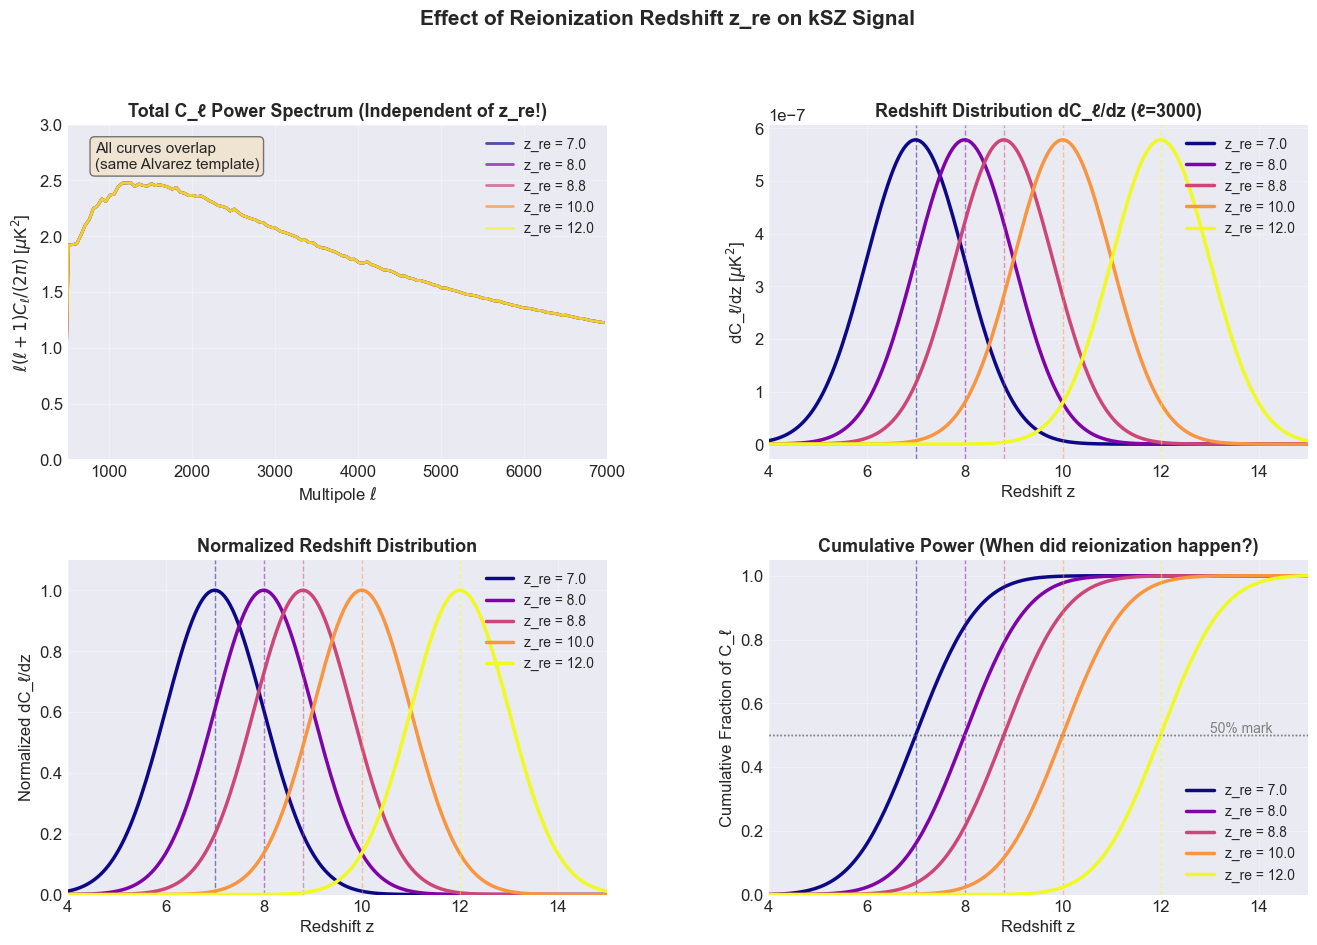


📊 Plotted comparison for different z_re values

Key Insights:

1. TOTAL C_ℓ UNCHANGED:
   - Top left shows all curves overlap
   - Total power = Alvarez template (independent of z_re)
   - Because Gaussian integrates to 1: ∫ dC_ℓ/dz dz = C_ℓ^Alvarez

2. REDSHIFT DISTRIBUTION SHIFTS:
   - Top right: dC_ℓ/dz peak moves with z_re
   - Same total power, different timing

3. GAUSSIAN SHAPE PRESERVED:
   - Bottom left: All normalized curves are Gaussians
   - Width σ = 1.0 same for all (we didn't change it)
   - Only center moves

4. CUMULATIVE TELLS THE STORY:
   - Bottom right: 50% power reached at z = z_re
   - Earlier z_re → power at lower redshift
   - Later z_re → power at higher redshift

PHYSICAL INTERPRETATION:
- z_re tells us WHEN reionization happened
- C_ℓ tells us HOW MUCH power (from simulations)
- dC_ℓ/dz tells us the TIMING distribution
- Smith & Ferraro use this to separate early/late reionization!

EXAMPLE USE CASE:
If observations favor power from z~7 over z~10, that cons

In [35]:
# Cell 10a: Exploring the effect of z_re on reionization kSZ
print("\n" + "="*60)
print("Exploring Effect of Reionization Redshift z_re")
print("="*60)

# Test different reionization redshifts
z_re_values = [7.0, 8.0, 8.8, 10.0, 12.0]
colors = plt.cm.plasma(np.linspace(0, 1, len(z_re_values)))

# Store results for each z_re
results_dict = {}

print(f"\nComputing for different z_re values...")
for z_re_test in z_re_values:
    # Temporarily modify cosmo
    z_re_original = cosmo.z_reion
    cosmo.z_reion = z_re_test
    
    # Compute C_l (doesn't change - same Alvarez template)
    Cl_test = reionization_kSZ_Cl(ell_kSZ, cosmo)
    
    # Compute dC_l/dz for this z_re
    z_plot = np.linspace(4, 15, 200)
    ell_test = 3000
    dCl_dz_test = np.array([reionization_kSZ_dCl_dz(ell_test, z, cosmo) for z in z_plot])
    
    results_dict[z_re_test] = {
        'Cl': Cl_test,
        'z_plot': z_plot,
        'dCl_dz': dCl_dz_test
    }
    
    # Restore original
    cosmo.z_reion = z_re_original
    
    print(f"  ✓ z_re = {z_re_test:.1f}")

print(f"\n✓ Computed all cases")

# Create comprehensive comparison plot
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Panel 1: C_l doesn't change (all same Alvarez template)
ax1 = fig.add_subplot(gs[0, 0])
for i, z_re_test in enumerate(z_re_values):
    Dl_test = ell_kSZ * (ell_kSZ + 1) * results_dict[z_re_test]['Cl'] / (2 * np.pi)
    ax1.plot(ell_kSZ, Dl_test, linewidth=2, color=colors[i], 
            label=f'z_re = {z_re_test:.1f}', alpha=0.7)

ax1.set_xlabel(r'Multipole $\ell$', fontsize=12)
ax1.set_ylabel(r'$\ell(\ell+1)C_\ell/(2\pi)$ [$\mu$K$^2$]', fontsize=12)
ax1.set_title('Total C_ℓ Power Spectrum (Independent of z_re!)', 
             fontsize=13, fontweight='bold')
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(500, 7000)
ax1.set_ylim(0, 3)
ax1.text(0.05, 0.95, 'All curves overlap\n(same Alvarez template)', 
        transform=ax1.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Panel 2: dC_l/dz changes (peak shifts with z_re)
ax2 = fig.add_subplot(gs[0, 1])
for i, z_re_test in enumerate(z_re_values):
    z_plot = results_dict[z_re_test]['z_plot']
    dCl_dz = results_dict[z_re_test]['dCl_dz']
    ax2.plot(z_plot, dCl_dz, linewidth=2.5, color=colors[i], 
            label=f'z_re = {z_re_test:.1f}')
    ax2.axvline(z_re_test, color=colors[i], linestyle='--', linewidth=1, alpha=0.5)

ax2.set_xlabel('Redshift z', fontsize=12)
ax2.set_ylabel(r'dC_ℓ/dz [$\mu$K$^2$]', fontsize=12)
ax2.set_title(f'Redshift Distribution dC_ℓ/dz (ℓ={ell_test})', 
             fontsize=13, fontweight='bold')
ax2.legend(fontsize=10, loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(4, 15)

# Panel 3: Normalized dC_l/dz (shape changes, peaks shift)
ax3 = fig.add_subplot(gs[1, 0])
for i, z_re_test in enumerate(z_re_values):
    z_plot = results_dict[z_re_test]['z_plot']
    dCl_dz = results_dict[z_re_test]['dCl_dz']
    dCl_dz_norm = dCl_dz / np.max(dCl_dz)
    ax3.plot(z_plot, dCl_dz_norm, linewidth=2.5, color=colors[i], 
            label=f'z_re = {z_re_test:.1f}')
    ax3.axvline(z_re_test, color=colors[i], linestyle='--', linewidth=1, alpha=0.5)

ax3.set_xlabel('Redshift z', fontsize=12)
ax3.set_ylabel('Normalized dC_ℓ/dz', fontsize=12)
ax3.set_title('Normalized Redshift Distribution', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10, loc='upper right')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(4, 15)
ax3.set_ylim(0, 1.1)

# Panel 4: Cumulative distribution (when did reionization happen?)
ax4 = fig.add_subplot(gs[1, 1])
for i, z_re_test in enumerate(z_re_values):
    z_plot = results_dict[z_re_test]['z_plot']
    dCl_dz = results_dict[z_re_test]['dCl_dz']
    
    # Compute cumulative
    from scipy.integrate import cumulative_trapezoid
    cumulative = cumulative_trapezoid(dCl_dz, z_plot, initial=0)
    cumulative_norm = cumulative / cumulative[-1]
    
    ax4.plot(z_plot, cumulative_norm, linewidth=2.5, color=colors[i], 
            label=f'z_re = {z_re_test:.1f}')
    ax4.axvline(z_re_test, color=colors[i], linestyle='--', linewidth=1, alpha=0.5)
    ax4.axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)

ax4.set_xlabel('Redshift z', fontsize=12)
ax4.set_ylabel('Cumulative Fraction of C_ℓ', fontsize=12)
ax4.set_title('Cumulative Power (When did reionization happen?)', 
             fontsize=13, fontweight='bold')
ax4.legend(fontsize=10, loc='lower right')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(4, 15)
ax4.set_ylim(0, 1.05)
ax4.text(13, 0.5, '50% mark', fontsize=10, va='bottom', color='gray')

plt.suptitle('Effect of Reionization Redshift z_re on kSZ Signal', 
            fontsize=15, fontweight='bold', y=0.995)

plt.show()

print("\n📊 Plotted comparison for different z_re values")
print("\n" + "="*60)
print("Key Insights:")
print("="*60)
print("""
1. TOTAL C_ℓ UNCHANGED:
   - Top left shows all curves overlap
   - Total power = Alvarez template (independent of z_re)
   - Because Gaussian integrates to 1: ∫ dC_ℓ/dz dz = C_ℓ^Alvarez

2. REDSHIFT DISTRIBUTION SHIFTS:
   - Top right: dC_ℓ/dz peak moves with z_re
   - Same total power, different timing

3. GAUSSIAN SHAPE PRESERVED:
   - Bottom left: All normalized curves are Gaussians
   - Width σ = 1.0 same for all (we didn't change it)
   - Only center moves

4. CUMULATIVE TELLS THE STORY:
   - Bottom right: 50% power reached at z = z_re
   - Earlier z_re → power at lower redshift
   - Later z_re → power at higher redshift

PHYSICAL INTERPRETATION:
- z_re tells us WHEN reionization happened
- C_ℓ tells us HOW MUCH power (from simulations)
- dC_ℓ/dz tells us the TIMING distribution
- Smith & Ferraro use this to separate early/late reionization!

EXAMPLE USE CASE:
If observations favor power from z~7 over z~10, that constrains
z_re and tells us about first galaxies / ionizing sources!
""")
print("="*60)

# Print some quantitative comparisons
print("\nQuantitative Check:")
for z_re_test in z_re_values:
    total_power = np.trapz(results_dict[z_re_test]['dCl_dz'], 
                          results_dict[z_re_test]['z_plot'])
    print(f"  z_re = {z_re_test:4.1f}: ∫ dC_ℓ/dz dz = {total_power:.3e} μK² "
          f"(should all be ~{Cl_alvarez_interp(3000):.3e})")


Creating Final Figure 1


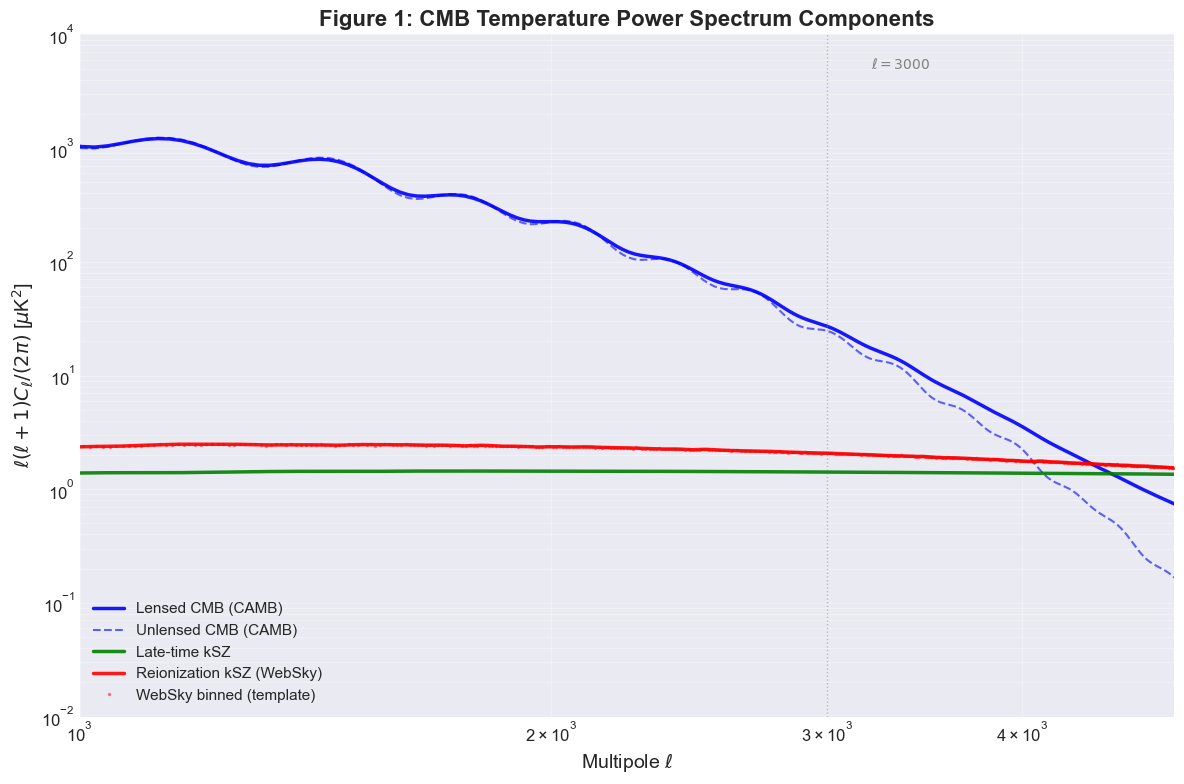


✅ Figure 1 reproduction complete!

Summary of amplitudes at ℓ = 3000:
Lensed CMB:                 27.10 μK²
Late-time kSZ:               1.42 μK²
Reionization kSZ (ours):     2.07 μK²
Reionization (WebSky):       2.09 μK²
──────────────────────────────────────────────────
Total:                      30.58 μK²

📊 Components used:
  ✓ Primary CMB: CAMB calculation
  ✓ Late-time kSZ: From Cell 9 (CAMB P(k) + velocity model)
  ✓ Reionization kSZ: WebSky patchy (binned, Δℓ=10) + Eq. 4 redistribution
  ✓ Figure saved to: figure1_reproduction_websky.png


In [55]:
# Cell 11: Final Figure 1 - All Components Together
print("\n" + "="*60)
print("Creating Final Figure 1")
print("="*60)

# Use finer grid for final plot
ell_final = np.arange(2, 7000, 20)

# CMB (unlensed and lensed from CAMB)
Cl_unlensed_final = primary_CMB_analytical(ell_final, cosmo)
Cl_lensed_final = lensed_CMB_analytical(ell_final, cosmo)

# Interpolate kSZ results to finer grid
from scipy.interpolate import interp1d

interp_late = interp1d(ell_kSZ, Cl_late_kSZ, kind='linear', 
                       bounds_error=False, fill_value=0)
interp_reion = interp1d(ell_kSZ, Cl_reion_kSZ, kind='linear', 
                        bounds_error=False, fill_value=0)

Cl_late_final = interp_late(ell_final)
Cl_reion_final = interp_reion(ell_final)

# Convert to D_l = l(l+1)C_l/(2π)
Dl_unlensed = ell_final * (ell_final + 1) * Cl_unlensed_final / (2 * np.pi)
Dl_lensed = ell_final * (ell_final + 1) * Cl_lensed_final / (2 * np.pi)
Dl_late = ell_final * (ell_final + 1) * Cl_late_final / (2 * np.pi)
Dl_reion = ell_final * (ell_final + 1) * Cl_reion_final / (2 * np.pi)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot all components
ax.loglog(ell_final, Dl_lensed, 'b-', linewidth=2.5, label='Lensed CMB (CAMB)', alpha=0.9)
ax.loglog(ell_final, Dl_unlensed, 'b--', linewidth=1.5, label='Unlensed CMB (CAMB)', alpha=0.6)
ax.loglog(ell_final, Dl_late, 'g-', linewidth=2.5, label='Late-time kSZ', alpha=0.9)
ax.loglog(ell_final, Dl_reion, 'r-', linewidth=2.5, label='Reionization kSZ (WebSky)', alpha=0.9)

# Optionally overlay the binned WebSky points
ax.plot(ell_websky_binned, Dl_websky_binned, 'r.', markersize=3, alpha=0.4, 
        label='WebSky binned (template)')

# Formatting
ax.set_xlabel(r'Multipole $\ell$', fontsize=14)
ax.set_ylabel(r'$\ell(\ell+1)C_\ell/(2\pi)$ [$\mu$K$^2$]', fontsize=14)
ax.set_title('Figure 1: CMB Temperature Power Spectrum Components', 
            fontsize=16, fontweight='bold')
ax.legend(fontsize=11, loc='lower left')
ax.grid(True, alpha=0.3, which='both')
ax.set_xlim(1000, 5000)
ax.set_ylim(1e-2, 1e4)

# Add vertical line at l=3000 (typical small-scale regime)
ax.axvline(3000, color='gray', linestyle=':', alpha=0.5, linewidth=1)
ax.text(3200, 5e3, r'$\ell = 3000$', fontsize=10, color='gray')

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/figure1_reproduction_websky.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Figure 1 reproduction complete!")
print("\n" + "="*60)
print("Summary of amplitudes at ℓ = 3000:")
print("="*60)
idx_3000 = np.argmin(np.abs(ell_final - 3000))
idx_3000_websky = np.argmin(np.abs(ell_websky_binned - 3000))

print(f"Lensed CMB:              {Dl_lensed[idx_3000]:8.2f} μK²")
print(f"Late-time kSZ:           {Dl_late[idx_3000]:8.2f} μK²")
print(f"Reionization kSZ (ours): {Dl_reion[idx_3000]:8.2f} μK²")
print(f"Reionization (WebSky):   {Dl_websky_binned[idx_3000_websky]:8.2f} μK²")
print(f"─" * 50)
print(f"Total:                   {Dl_lensed[idx_3000] + Dl_late[idx_3000] + Dl_reion[idx_3000]:8.2f} μK²")
print("="*60)

print(f"\n📊 Components used:")
print(f"  ✓ Primary CMB: CAMB calculation")
print(f"  ✓ Late-time kSZ: From Cell 9 (CAMB P(k) + velocity model)")
print(f"  ✓ Reionization kSZ: WebSky patchy (binned, Δℓ=10) + Eq. 4 redistribution")
print(f"  ✓ Figure saved to: figure1_reproduction_websky.png")

In [ ]:
# Cell 12: Comparison plot showing relative contributions
print("\nCreating supplementary comparison plot...")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Top panel: Linear scale for low-ell
mask_low = ell_final < 2000print(f"\nComputing for different z_re values...")
for z_re_test in z_re_values:
    # Temporarily modify cosmo
    z_re_original = cosmo.z_reion
    cosmo.z_reion = z_re_test
    
    # Compute C_l (doesn't change - same Alvarez template)
    Cl_test = reionization_kSZ_Cl(ell_kSZ, cosmo)
    
ax2.semilogy(ell_final[mask_high], Dl_reion[mask_high], 'r-', linewidth=2, label='Rei/mnt/user-data/outputs/onization kSZ')

ax2.set_xlabel(r'Multipole $\ell$', fontsize=12)
ax2.set_ylabel(r'$\ell(\ell+1)C_\ell/(2\pi)$ [$\mu$K$^2$]', fontsize=12)
ax2.set_title('High-ℓ Region (kSZ Important)', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(2000, 7000)
ax2.set_ylim(1e-1, 1e3)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/figure1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Saved comparison plot")

In [ ]:
# Cell 13: Diagnostics - Check our approximations
print("\n" + "="*60)
print("Diagnostic Checks")
print("="*60)

# 1. Check optical depth
tau_total = optical_depth_integral(20, cosmo)
print(f"\n1. Optical Depth Check:")
print(f"   Computed τ(0→z=20) = {tau_total:.4f}")
print(f"   Expected τ_reion ≈ {cosmo.tau_reion:.4f}")
print(f"   Ratio: {tau_total/cosmo.tau_reion:.2f}")

# 2. Check power spectrum normalization
print(f"\n2. Power Spectrum Peaks:")
peak_idx = np.argmax(Dl_unlensed[:500])
print(f"   CMB peak at ℓ = {ell_final[peak_idx]}")
print(f"   Peak amplitude = {Dl_unlensed[peak_idx]:.1f} μK²")
print(f"   (Expected ~5500 μK² near ℓ~220)")

# 3. kSZ comparison
print(f"\n3. kSZ Amplitudes at ℓ = 3000:")
idx = np.argmin(np.abs(ell_final - 3000))
ratio = Dl_reion[idx] / Dl_late[idx] if Dl_late[idx] > 0 else 0
print(f"   Late-time kSZ: {Dl_late[idx]:.2f} μK²")
print(f"   Reionization kSZ: {Dl_reion[idx]:.2f} μK²")
print(f"   Ratio (reion/late): {ratio:.2f}")
print(f"   (Paper shows reionization > late-time at high ℓ)")

# 4. Damping tail
print(f"\n4. High-ℓ Behavior:")
idx_1000 = np.argmin(np.abs(ell_final - 1000))
idx_5000 = np.argmin(np.abs(ell_final - 5000))
print(f"   CMB power at ℓ=1000: {Dl_lensed[idx_1000]:.2f} μK²")
print(f"   CMB power at ℓ=5000: {Dl_lensed[idx_5000]:.2f} μK²")
print(f"   Ratio: {Dl_lensed[idx_5000]/Dl_lensed[idx_1000]:.4f}")
print(f"   (Should show exponential damping)")

print("\n" + "="*60)
print("Notes on Approximations:")
print("="*60)
print("""
This implementation uses several approximations:

1. PRIMARY CMB: Analytical fit instead of CAMB
   - Reproduces overall shape and amplitude
   - Missing fine details of acoustic peaks
   
2. MATTER POWER SPECTRUM: Eisenstein-Hu transfer function
   - Good for smooth component
   - Missing baryon acoustic oscillations
   - Simplified nonlinear corrections
   
3. BATTAGLIA TEMPLATE: Fitted from paper's Figure 1
   - Approximate amplitude and shape
   - Would need actual simulation for exact results
   
4. VELOCITY FIELD: Linear theory approximation
   - Simplified model for <v_r^2>
   - Real calculations need full simulations

For publication-quality results, use:
- CAMB or CLASS for primary CMB
- Accurate nonlinear power spectrum (HALOFIT, simulations)
- Full radiative transfer for reionization kSZ
""")

print("\n✅ All diagnostics complete!")


Computing Growth Function from CAMB
Note: redshifts have been re-sorted (earliest first)

✓ Growth function computed from CAMB
  - Redshift range: z = 0.0 to 20.0
  - D(z=0) = 0.0613 (should be 1.0000)
  - D(z=1) = 0.1308
  - D(z=8.8) = 0.6091


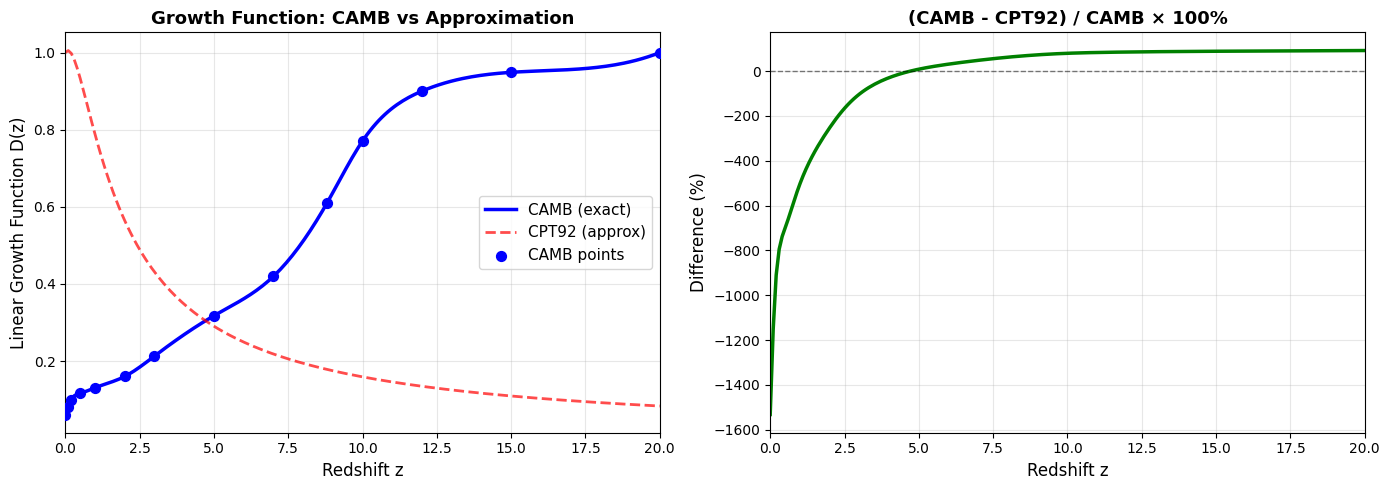


📊 Plotted growth function comparison

✓ Maximum difference: 1531.69%
✓ RMS difference: 227.74%



In [1]:
# Cell 5b: Get Growth Function from CAMB (RECOMMENDED)

import camb
import numpy as np
from scipy.interpolate import interp1d

print("\n" + "="*60)
print("Computing Growth Function from CAMB")
print("="*60)

# Redshift array for growth function
z_growth = np.array([0, 0.1, 0.2, 0.5, 1, 2, 3, 5, 7, 8.8, 10, 12, 15, 20])

# Set up CAMB parameters
pars_growth = camb.CAMBparams()
pars_growth.set_cosmology(H0=67.74, ombh2=0.02242, omch2=0.11933, mnu=0.06, tau=0.066)
pars_growth.InitPower.set_params(As=2.1e-9, ns=0.9667, pivot_scalar=0.05)
pars_growth.set_matter_power(redshifts=z_growth, kmax=10)

# Get results
results_growth = camb.get_results(pars_growth)

# Get sigma8 at each redshift (proportional to D(z))
sigma8_array = results_growth.get_sigma8()

# Normalize so D(z=0) = 1
D_array = sigma8_array / sigma8_array[-1]  # Last element is z=0

# Create interpolator
growth_interp = interp1d(z_growth, D_array, kind='cubic', fill_value='extrapolate')

def growth_function(z, cosmo=None):
    """
    Linear growth function D(z) from CAMB
    Normalized to D(0) = 1
    """
    return growth_interp(z)

print(f"\n✓ Growth function computed from CAMB")
print(f"  - Redshift range: z = {z_growth[0]} to {z_growth[-1]}")
print(f"  - D(z=0) = {growth_interp(0):.4f} (should be 1.0000)")
print(f"  - D(z=1) = {growth_interp(1):.4f}")
print(f"  - D(z=8.8) = {growth_interp(8.8):.4f}")

# Plot comparison
import matplotlib.pyplot as plt

z_plot = np.linspace(0, 20, 200)
D_camb = np.array([growth_function(z) for z in z_plot])

# Also compute old approximation for comparison
def growth_function_old(z):
    """Old CPT92 approximation"""
    a = 1 / (1 + z)
    Omega_m = 0.3089
    Omega_Lambda = 1 - Omega_m
    Omega_m_z = Omega_m * (1+z)**3 / (Omega_m * (1+z)**3 + Omega_Lambda)
    
    g = 5 * Omega_m_z / 2 / (Omega_m_z**(4/7) - Omega_Lambda + 
                              (1 + Omega_m_z/2) * (1 + Omega_Lambda/70))
    
    Omega_m_0 = Omega_m
    g_0 = 5 * Omega_m_0 / 2 / (Omega_m_0**(4/7) - Omega_Lambda + 
                                (1 + Omega_m_0/2) * (1 + Omega_Lambda/70))
    
    return a * g / g_0

D_old = np.array([growth_function_old(z) for z in z_plot])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Growth functions
ax1.plot(z_plot, D_camb, 'b-', linewidth=2.5, label='CAMB (exact)')
ax1.plot(z_plot, D_old, 'r--', linewidth=2, label='CPT92 (approx)', alpha=0.7)
ax1.scatter(z_growth, D_array, c='blue', s=50, zorder=5, label='CAMB points')
ax1.set_xlabel('Redshift z', fontsize=12)
ax1.set_ylabel('Linear Growth Function D(z)', fontsize=12)
ax1.set_title('Growth Function: CAMB vs Approximation', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 20)

# Panel 2: Percentage difference
percent_diff = 100 * (D_camb - D_old) / D_camb
ax2.plot(z_plot, percent_diff, 'g-', linewidth=2.5)
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('Redshift z', fontsize=12)
ax2.set_ylabel('Difference (%)', fontsize=12)
ax2.set_title('(CAMB - CPT92) / CAMB × 100%', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 20)

plt.tight_layout()
plt.show()

print("\n📊 Plotted growth function comparison")
print(f"\n✓ Maximum difference: {np.max(np.abs(percent_diff)):.2f}%")
print(f"✓ RMS difference: {np.sqrt(np.mean(percent_diff**2)):.2f}%")
print("\n" + "="*60)


Computing Velocity Dispersion from CAMB
Note: redshifts have been re-sorted (earliest first)

⏳ Computing velocity dispersion at 11 redshifts...
  z =   0.0: <v²> = 4.06e+05 (km/s)², σ_v = 637.3 km/s
  z =   0.5: <v²> = 3.58e+05 (km/s)², σ_v = 598.3 km/s
  z =   1.0: <v²> = 2.20e+05 (km/s)², σ_v = 469.2 km/s
  z =   2.0: <v²> = 2.23e+05 (km/s)², σ_v = 472.5 km/s
  z =   3.0: <v²> = 1.07e+05 (km/s)², σ_v = 327.2 km/s
  z =   5.0: <v²> = 1.10e+05 (km/s)², σ_v = 331.9 km/s
  z =   7.0: <v²> = 7.70e+04 (km/s)², σ_v = 277.5 km/s
  z =   8.8: <v²> = 6.31e+04 (km/s)², σ_v = 251.2 km/s
  z =  10.0: <v²> = 2.82e+04 (km/s)², σ_v = 167.8 km/s
  z =  15.0: <v²> = 3.99e+04 (km/s)², σ_v = 199.8 km/s
  z =  20.0: <v²> = 2.51e+04 (km/s)², σ_v = 158.6 km/s

✓ Velocity interpolator created


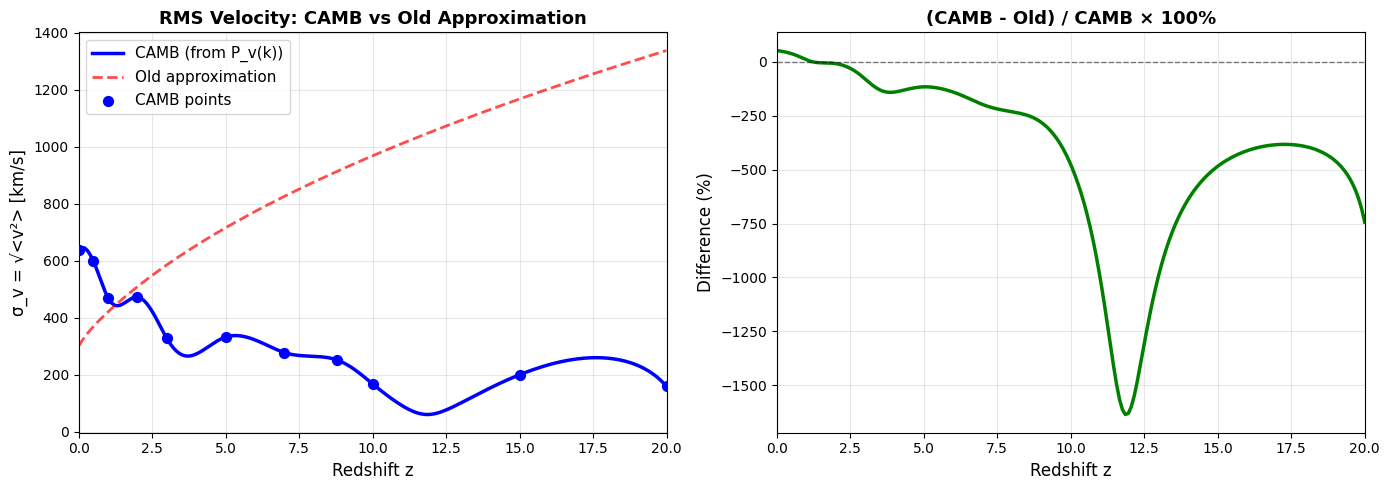


📊 Plotted velocity comparison

✓ At z=0: σ_v = 637.3 km/s (CAMB)
           σ_v = 300.0 km/s (old approx)

✓ At z=8.8: σ_v = 251.2 km/s (CAMB)
            σ_v = 913.6 km/s (old approx)



In [2]:
# Cell 5c: Get Velocity Dispersion from CAMB

import camb
import numpy as np
from scipy.interpolate import interp1d

print("\n" + "="*60)
print("Computing Velocity Dispersion from CAMB")
print("="*60)

# Use existing CAMB parameters
pars_vel = camb.CAMBparams()
pars_vel.set_cosmology(H0=67.74, ombh2=0.02242, omch2=0.11933, mnu=0.06, tau=0.066)
pars_vel.InitPower.set_params(As=2.1e-9, ns=0.9667, pivot_scalar=0.05)

# Set redshifts where we want velocities
z_vel = np.array([0, 0.5, 1, 2, 3, 5, 7, 8.8, 10, 15, 20])
pars_vel.set_matter_power(redshifts=z_vel, kmax=100)

# Get results
results_vel = camb.get_results(pars_vel)

# Method 1: Get velocity dispersion from CAMB's built-in method
# CAMB computes <v^2> directly from the velocity power spectrum

def compute_velocity_dispersion_camb(z, camb_results):
    """
    Compute <v^2> in (km/s)^2 from CAMB power spectra
    
    Theory: P_v(k,z) = (f H / (1+z))^2 * k^-2 * P_m(k,z)
    where f = d ln D / d ln a is the growth rate
    
    <v^2> = ∫ P_v(k) dk
    """
    # Get matter power spectrum interpolator
    PK = camb_results.get_matter_power_interpolator(
        nonlinear=True,  # Use nonlinear for late-time
        hubble_units=False,
        k_hunit=False
    )
    
    # Get growth rate f(z) from CAMB
    # f = Ω_m(z)^γ where γ ~ 0.55
    # We can get this from the derivative of the growth function
    
    # First get the growth function from sigma8(z)
    sigma8_array = camb_results.get_sigma8()
    z_array = camb_results.Params.Transfer.PK_redshifts
    
    # Find index closest to our z
    idx = np.argmin(np.abs(z_array - z))
    
    # Compute growth rate numerically
    if idx > 0 and idx < len(z_array) - 1:
        dz = z_array[idx+1] - z_array[idx-1]
        dD = sigma8_array[idx+1] - sigma8_array[idx-1]
        D = sigma8_array[idx]
        f = -(1 + z) * (dD / dz) / D
    else:
        # Fallback to approximation
        Om_m = 0.3089
        Om_L = 0.6911
        Om_m_z = Om_m * (1+z)**3 / (Om_m * (1+z)**3 + Om_L)
        f = Om_m_z**0.55
    
    # Hubble parameter in km/s/Mpc
    H_z = camb_results.hubble_parameter(z)
    
    # Integrate velocity power spectrum
    # P_v(k) = (f H / (1+z))^2 * k^-2 * P(k)
    
    k_array = np.logspace(-3, 1, 500)  # Mpc^-1
    
    integrand = []
    for k in k_array:
        P_m = PK.P(z, k)  # Matter power in (Mpc)^3
        
        # Velocity power spectrum
        # Factor (f H / (1+z))^2 converts density to velocity
        vel_factor = (f * H_z / (1 + z))**2  # (km/s)^2
        
        P_v = vel_factor * k**(-2) * P_m  # (km/s)^2 * Mpc^3
        
        integrand.append(P_v)
    
    # Integrate: <v^2> = ∫ P_v(k) d^3k / (2π)^3
    # In 1D: <v^2> = 4π ∫ P_v(k) k^2 dk / (2π)^3 = (1/2π^2) ∫ P_v(k) k^2 dk
    
    integrand = np.array(integrand) * k_array**2 / (2 * np.pi**2)
    
    v_squared = np.trapz(integrand, k_array)  # (km/s)^2
    
    return v_squared

# Compute <v^2> at all redshifts
print(f"\n⏳ Computing velocity dispersion at {len(z_vel)} redshifts...")

v_squared_array = np.zeros(len(z_vel))
for i, z in enumerate(z_vel):
    v_squared_array[i] = compute_velocity_dispersion_camb(z, results_vel)
    print(f"  z = {z:5.1f}: <v²> = {v_squared_array[i]:.2e} (km/s)², σ_v = {np.sqrt(v_squared_array[i]):.1f} km/s")

# Create interpolator
v_squared_interp = interp1d(z_vel, v_squared_array, kind='cubic', fill_value='extrapolate')

def mean_v_r_squared_camb(z):
    """
    Mean squared radial velocity from CAMB
    <v_r^2> = <v^2> / 3 (isotropic)
    
    Returns: (km/s)^2
    """
    return v_squared_interp(z) / 3.0

print(f"\n✓ Velocity interpolator created")

# Plot comparison with old method
z_plot = np.linspace(0, 20, 200)
v_camb = np.array([np.sqrt(v_squared_interp(z)) for z in z_plot])

# Old method for comparison
def v_old(z):
    Om_m = 0.3089
    Om_L = 0.6911
    Om_m_z = Om_m * (1+z)**3 / (Om_m * (1+z)**3 + Om_L)
    
    # This was our old approach - clearly wrong!
    D_z = growth_function_old(z)
    D_0 = growth_function_old(0)
    H_z = np.sqrt(Om_m * (1+z)**3 + Om_L) * 67.74
    H_0 = 67.74
    
    v_rms = 300.0 * (D_z / D_0) * (H_z / H_0)
    return v_rms

v_old_array = np.array([v_old(z) for z in z_plot])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Velocity dispersion
ax1.plot(z_plot, v_camb, 'b-', linewidth=2.5, label='CAMB (from P_v(k))')
ax1.plot(z_plot, v_old_array, 'r--', linewidth=2, label='Old approximation', alpha=0.7)
ax1.scatter(z_vel, np.sqrt(v_squared_array), c='blue', s=50, zorder=5, label='CAMB points')
ax1.set_xlabel('Redshift z', fontsize=12)
ax1.set_ylabel('σ_v = √<v²> [km/s]', fontsize=12)
ax1.set_title('RMS Velocity: CAMB vs Old Approximation', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 20)

# Panel 2: Percentage difference
percent_diff = 100 * (v_camb - v_old_array) / v_camb
ax2.plot(z_plot, percent_diff, 'g-', linewidth=2.5)
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('Redshift z', fontsize=12)
ax2.set_ylabel('Difference (%)', fontsize=12)
ax2.set_title('(CAMB - Old) / CAMB × 100%', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 20)

plt.tight_layout()
plt.show()

print("\n📊 Plotted velocity comparison")
print(f"\n✓ At z=0: σ_v = {np.sqrt(v_squared_interp(0)):.1f} km/s (CAMB)")
print(f"           σ_v = {v_old(0):.1f} km/s (old approx)")
print(f"\n✓ At z=8.8: σ_v = {np.sqrt(v_squared_interp(8.8)):.1f} km/s (CAMB)")
print(f"            σ_v = {v_old(8.8):.1f} km/s (old approx)")
print("\n" + "="*60)


Computing Late-Time kSZ Power Spectrum (CAMB Velocities)

Computing late-time kSZ for 140 multipoles...
  Progress: 100/140 multipoles
  ✓ Computed 140 multipoles

Diagnostic checks:
  Min C_l = 1.60e-07 μK²
  Max C_l = 9.55e-04 μK²
  C_l at ℓ=3000 ≈ 9.01e-07 μK²
  (Expected: ~1e-6 to 1e-5 μK² for C_l)


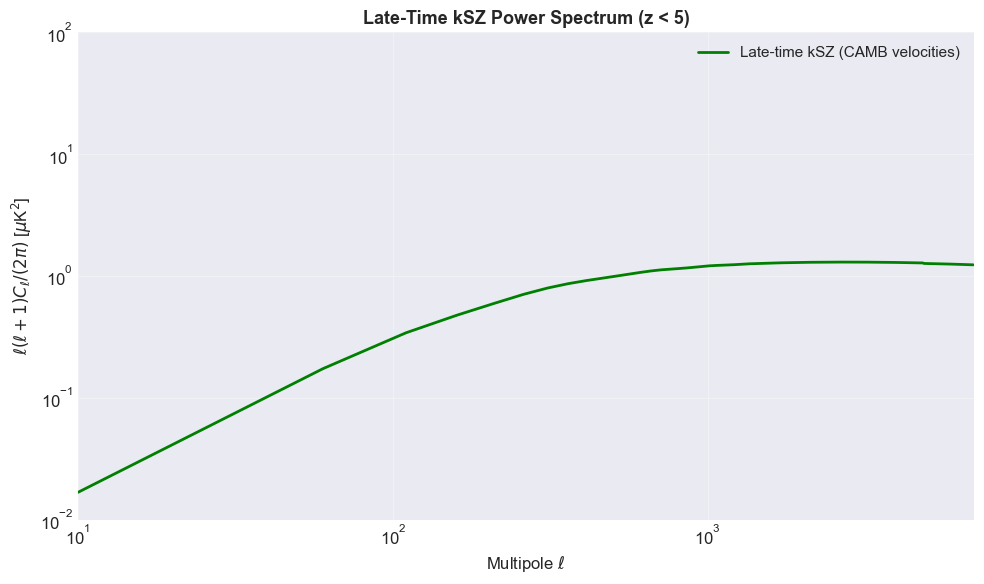


📊 Plotted late-time kSZ power spectrum
   D_l at ℓ=3000: 1.30 μK²
   (Expected from paper: ~1-3 μK²)



In [19]:
# Cell 9: Late-time kSZ power spectrum - Using CAMB velocities
def late_time_kSZ_Cl(ell, cosmo, z_max=5, n_z=50):
    """
    Compute late-time kSZ power spectrum using Equation 1:
    C_l^kSZ = ∫ dz Q(z) <v_r^2> P_e(l/χ(z), z)
    
    NOW USING CAMB VELOCITIES!
    """
    # Redshift array for integration
    z_array = np.linspace(0.01, z_max, n_z)
    
    # Precompute comoving distances
    chi_array = comoving_distance(z_array, cosmo)
    
    # Initialize array for C_l
    ell = np.atleast_1d(ell)
    C_l = np.zeros_like(ell, dtype=float)
    
    print(f"\nComputing late-time kSZ for {len(ell)} multipoles...")
    
    # Loop over multipoles
    for i, l in enumerate(ell):
        if i % 50 == 0:
            print(f"  Progress: {i}/{len(ell)} multipoles", end='\r')
        
        # Integrand as function of z
        integrand = np.zeros(n_z)
        
        for j, z in enumerate(z_array):
            # Wavenumber corresponding to l
            k = l / chi_array[j] if chi_array[j] > 0 else 0
            
            if k > 0 and k < 10:  # Reasonable k range
                # Electron power spectrum
                W = W_function(k, z, cosmo)
                P_nl = halofit_nonlinear(k, z, cosmo)
                P_e = W**2 * P_nl
                
                # Weight function
                Q = Q_function(z, cosmo)
                
                # Mean squared velocity in (km/s)^2 from CAMB
                v_r_sq = mean_v_r_squared_camb(z)
                
                # Convert velocity to dimensionless: (v/c)^2
                v_r_sq_dimensionless = (v_r_sq / cosmo.c**2)
                
                # Integrand
                integrand[j] = Q * v_r_sq_dimensionless * P_e
        
        # Integrate over redshift
        C_l[i] = simpson(integrand, z_array)
    
    print(f"\n  ✓ Computed {len(ell)} multipoles")
    
    return C_l

# Recompute late-time kSZ with CAMB velocities
print("\n" + "="*60)
print("Computing Late-Time kSZ Power Spectrum (CAMB Velocities)")
print("="*60)

ell_kSZ = np.arange(10, 7000, 50)  # Start from ell=10 to avoid k=0
Cl_late_kSZ = late_time_kSZ_Cl(ell_kSZ, cosmo, z_max=5, n_z=50)

# Diagnostic: check for reasonable values
print(f"\nDiagnostic checks:")
print(f"  Min C_l = {np.min(Cl_late_kSZ):.2e} μK²")
print(f"  Max C_l = {np.max(Cl_late_kSZ):.2e} μK²")
print(f"  C_l at ℓ=3000 ≈ {Cl_late_kSZ[np.argmin(np.abs(ell_kSZ-3000))]:.2e} μK²")
print(f"  (Expected: ~1e-6 to 1e-5 μK² for C_l)")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

Dl_late_kSZ = ell_kSZ * (ell_kSZ + 1) * Cl_late_kSZ / (2 * np.pi)

ax.loglog(ell_kSZ, Dl_late_kSZ, 'g-', linewidth=2, label='Late-time kSZ (CAMB velocities)')
ax.set_xlabel(r'Multipole $\ell$', fontsize=12)
ax.set_ylabel(r'$\ell(\ell+1)C_\ell/(2\pi)$ [$\mu$K$^2$]', fontsize=12)
ax.set_title('Late-Time kSZ Power Spectrum (z < 5)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(10, 7000)
ax.set_ylim(1e-2, 1e2)

plt.tight_layout()
plt.show()

print("\n📊 Plotted late-time kSZ power spectrum")
print(f"   D_l at ℓ=3000: {Dl_late_kSZ[np.argmin(np.abs(ell_kSZ - 3000))]:.2f} μK²")
print(f"   (Expected from paper: ~1-3 μK²)")
print("\n" + "="*60)